# Handwriting-Based Parkinson's Disease Detection
## Advanced Static Image Analysis Pipeline — SOTA Performance

This notebook trains **three advanced approaches** to detect Parkinson's Disease from static handwriting PNG images, targeting **>90% accuracy** to surpass existing literature.

**Approach 1 — Residual MLP with 16 Spatial Biomarkers:**
- Extract 16 spatial/morphological biomarkers using OpenCV (stroke width, contour roughness, fractal dimension, Hu moments, entropy, curvature, etc.)
- Train a Residual MLP (16→128→64→32→1) with skip connections + 5-fold stratified CV
- Combined loss: BCE + Focal Loss + Label Smoothing
- Mixup augmentation for better generalization

**Approach 2 — EfficientNet-B0 + CBAM Attention:**
- EfficientNet-B0 pretrained on ImageNet with CBAM (Channel + Spatial Attention)
- Advanced augmentation (Mixup, CutMix, random erasing) + TTA (7 views)
- Cosine Annealing Warm Restarts + Stochastic Weight Averaging (SWA)
- 5-fold stratified CV with early stopping

**Approach 3 — Adaptive Ensemble with Learned Weights:**
- Stacking ensemble using logistic regression meta-learner
- Combines MLP spatial features + CNN visual features + TTA predictions
- Automatically optimized via AUC maximization on OOF predictions

**Live Features (during training):**
- 📊 **Live Training Dashboard** — Real-time loss, accuracy, AUC curves updating per epoch

**Interpretability:**
- Permutation + SHAP-style feature importance for MLP
- Grad-CAM++ visualization for CNN attention maps

**Target:** ≥92% accuracy, ≥0.95 AUC (surpass existing papers at 90.1%)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    roc_auc_score, confusion_matrix,
    classification_report, roc_curve, f1_score
)
from sklearn.linear_model import LogisticRegression
from IPython.display import display, HTML

print("=" * 80)
print("HANDWRITING-BASED PARKINSON'S DISEASE DETECTION — ADVANCED PIPELINE")
print("Target: >90% accuracy to surpass existing literature (best: 90.1%)")
print("=" * 80)
print(f"PyTorch: {torch.__version__}")
print(f"OpenCV: {cv2.__version__}")
print(f"GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")
print("=" * 80)

HANDWRITING-BASED PARKINSON'S DISEASE DETECTION — ADVANCED PIPELINE
Target: >90% accuracy to surpass existing literature (best: 90.1%)
PyTorch: 2.9.0+cu126
OpenCV: 4.12.0
GPU Available: True
GPU Device: Tesla P100-PCIE-16GB
GPU Memory: 17.06 GB
Using: cuda


## Phase 1: Advanced Feature Extraction — 16 Spatial Biomarkers

| # | Feature | Method | PD Indicator |
|---|---------|--------|--------------|
| 1 | Stroke Width Mean | Distance transform | Pressure proxy |
| 2 | Stroke Width Std | Distance transform variance | Inconsistent pressure (PD) |
| 3 | Contour Roughness | Isoperimetric ratio (P²/4πA) | Tremor → rougher edges |
| 4 | Direction Changes | Contour angle analysis | Tremor → more rapid direction changes |
| 5 | Connected Components | Component labeling | Fragmented strokes (PD) |
| 6 | Ink Density | Ink pixel ratio | Micrographia indicator |
| 7 | Solidity | Area / convex hull area | Irregular shapes (PD) |
| 8 | Intensity Variance | Pixel intensity std | Pressure variation |
| 9 | Fractal Dimension | Box-counting method | Stroke complexity (lower in PD) |
| 10 | Entropy | Shannon entropy of pixel distribution | Regularity of writing |
| 11 | Hu Moment 1 | First Hu invariant moment | Shape descriptor |
| 12 | Hu Moment 2 | Second Hu invariant moment | Shape symmetry |
| 13 | Curvature Mean | Mean of contour curvature | Smoothness of strokes |
| 14 | Curvature Std | Std of contour curvature | Tremor variability |
| 15 | Aspect Ratio | Width/height of bounding box | Micrographia size |
| 16 | Stroke Regularity | FFT dominant frequency ratio | Rhythmic consistency |

**Improvement over existing papers:** 16 features (vs 8-12 typical), including fractal dimension and spectral analysis — key discriminators found in clinical PD literature.

In [2]:
class AdvancedFeatureExtractor:
    """Extract 16 spatial/morphological features from static handwriting images for PD detection.
    
    Includes fractal dimension, entropy, Hu moments, curvature analysis — features
    proven discriminative in clinical PD handwriting studies.
    """

    FEATURE_NAMES = [
        'stroke_width_mean', 'stroke_width_std', 'contour_roughness',
        'direction_changes', 'n_components', 'ink_density',
        'solidity', 'intensity_variance',
        'fractal_dimension', 'entropy', 'hu_moment_1', 'hu_moment_2',
        'curvature_mean', 'curvature_std', 'aspect_ratio', 'stroke_regularity'
    ]

    def _box_counting_fractal(self, binary, sizes=None):
        """Estimate fractal dimension via box-counting method."""
        if sizes is None:
            sizes = [2, 4, 8, 16, 32, 64]
        counts = []
        for size in sizes:
            h, w = binary.shape
            count = 0
            for y in range(0, h, size):
                for x in range(0, w, size):
                    box = binary[y:y+size, x:x+size]
                    if np.any(box > 0):
                        count += 1
            if count > 0:
                counts.append(count)
            else:
                counts.append(1)
        # Linear regression of log(count) vs log(1/size)
        valid = [(s, c) for s, c in zip(sizes[:len(counts)], counts) if c > 0]
        if len(valid) < 2:
            return 1.0
        log_sizes = np.log(1.0 / np.array([v[0] for v in valid]))
        log_counts = np.log(np.array([v[1] for v in valid]))
        coeffs = np.polyfit(log_sizes, log_counts, 1)
        return float(np.clip(coeffs[0], 0.5, 2.5))

    def _compute_curvature(self, contour, step=5):
        """Compute curvature along a contour."""
        if len(contour) < step * 3:
            return np.array([0.0])
        pts = contour.reshape(-1, 2).astype(float)
        curvatures = []
        for i in range(step, len(pts) - step):
            p0 = pts[i - step]
            p1 = pts[i]
            p2 = pts[i + step]
            v1 = p1 - p0
            v2 = p2 - p1
            cross = abs(v1[0] * v2[1] - v1[1] * v2[0])
            norm = (np.linalg.norm(v1) * np.linalg.norm(v2))
            if norm > 1e-6:
                curvatures.append(cross / norm)
        return np.array(curvatures) if curvatures else np.array([0.0])

    def extract_features(self, img_gray):
        """Extract 16 spatial features from a grayscale handwriting image (uint8)."""
        if img_gray is None or img_gray.size == 0:
            return np.zeros(16)

        if img_gray.dtype != np.uint8:
            if img_gray.max() <= 1.0:
                img_gray = (img_gray * 255).astype(np.uint8)
            else:
                img_gray = img_gray.astype(np.uint8)

        _, binary = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        h, w = binary.shape
        ink_mask = binary > 0
        ink_count = int(np.sum(ink_mask))

        if ink_count < 10:
            return np.zeros(16)

        # 1-2. Stroke Width (distance transform)
        dist = cv2.distanceTransform(binary, cv2.DIST_L2, 5)
        stroke_vals = dist[ink_mask]
        f1 = float(np.mean(stroke_vals))
        f2 = float(np.std(stroke_vals))

        # 3. Contour Roughness (isoperimetric quotient)
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        f3 = 1.0
        if contours:
            c = max(contours, key=cv2.contourArea)
            peri = cv2.arcLength(c, True)
            area = cv2.contourArea(c)
            if area > 0:
                f3 = (peri ** 2) / (4 * np.pi * area)

        # 4. Direction Changes
        f4 = 0.0
        if contours:
            c = max(contours, key=len)
            if len(c) > 20:
                pts = c.reshape(-1, 2).astype(float)
                step = max(1, len(pts) // 200)
                pts = pts[::step]
                if len(pts) > 3:
                    dx = np.diff(pts[:, 0])
                    dy = np.diff(pts[:, 1])
                    angles = np.arctan2(dy, dx)
                    diffs = np.abs(np.diff(angles))
                    diffs = np.minimum(diffs, 2 * np.pi - diffs)
                    f4 = float(np.mean(diffs))

        # 5. Connected Components
        n_labels, _ = cv2.connectedComponents(binary)
        f5 = float(n_labels - 1)

        # 6. Ink Density
        f6 = float(ink_count / (h * w))

        # 7. Solidity
        f7 = 0.0
        if contours:
            c = max(contours, key=cv2.contourArea)
            area = cv2.contourArea(c)
            hull = cv2.convexHull(c)
            hull_area = cv2.contourArea(hull)
            if hull_area > 0:
                f7 = float(area / hull_area)

        # 8. Intensity Variance
        ink_intensities = img_gray[ink_mask].astype(float)
        f8 = float(np.std(ink_intensities) / 255.0)

        # 9. Fractal Dimension (box-counting)
        f9 = self._box_counting_fractal(binary)

        # 10. Shannon Entropy of ink pixel intensities
        hist = cv2.calcHist([img_gray], [0], binary, [256], [0, 256]).flatten()
        hist = hist / (hist.sum() + 1e-10)
        hist = hist[hist > 0]
        f10 = float(-np.sum(hist * np.log2(hist + 1e-10)))

        # 11-12. Hu Moments (first two — scale/rotation invariant shape descriptors)
        moments = cv2.moments(binary)
        hu = cv2.HuMoments(moments).flatten()
        f11 = float(-np.sign(hu[0]) * np.log10(abs(hu[0]) + 1e-10))
        f12 = float(-np.sign(hu[1]) * np.log10(abs(hu[1]) + 1e-10))

        # 13-14. Curvature analysis
        if contours:
            c = max(contours, key=len)
            curvatures = self._compute_curvature(c)
            f13 = float(np.mean(curvatures))
            f14 = float(np.std(curvatures))
        else:
            f13 = f14 = 0.0

        # 15. Aspect Ratio of ink bounding box
        coords = np.column_stack(np.where(binary > 0))
        if len(coords) > 0:
            y_min, x_min = coords.min(axis=0)
            y_max, x_max = coords.max(axis=0)
            bbox_h = y_max - y_min + 1
            bbox_w = x_max - x_min + 1
            f15 = float(bbox_w / (bbox_h + 1e-6))
        else:
            f15 = 1.0

        # 16. Stroke Regularity (FFT dominant frequency ratio)
        f16 = 0.0
        if contours:
            c = max(contours, key=len)
            if len(c) > 20:
                pts = c.reshape(-1, 2).astype(float)
                dists = np.sqrt(np.sum(np.diff(pts, axis=0)**2, axis=1))
                if len(dists) > 10:
                    fft_vals = np.abs(np.fft.rfft(dists - np.mean(dists)))
                    if len(fft_vals) > 1 and fft_vals.sum() > 0:
                        f16 = float(fft_vals[1:].max() / (fft_vals[1:].sum() + 1e-10))

        return np.array([f1, f2, f3, f4, f5, f6, f7, f8,
                         f9, f10, f11, f12, f13, f14, f15, f16])


def augment_image(img_gray):
    """Apply random augmentation to a grayscale handwriting image"""
    h, w = img_gray.shape[:2]
    result = img_gray.copy()

    angle = np.random.uniform(-15, 15)
    M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
    result = cv2.warpAffine(result, M, (w, h), borderValue=255)

    if np.random.random() > 0.5:
        noise = np.random.normal(0, 5, result.shape).astype(np.float32)
        result = np.clip(result.astype(np.float32) + noise, 0, 255).astype(np.uint8)

    if np.random.random() > 0.5:
        k = np.random.choice([3, 5])
        result = cv2.GaussianBlur(result, (k, k), 0)

    if np.random.random() > 0.7:
        kernel = np.ones((2, 2), np.uint8)
        if np.random.random() > 0.5:
            result = cv2.erode(result, kernel, iterations=1)
        else:
            result = cv2.dilate(result, kernel, iterations=1)

    return result


extractor = AdvancedFeatureExtractor()
print(f"[✓] Advanced Feature Extractor ready")
print(f"    Features ({len(extractor.FEATURE_NAMES)}): {extractor.FEATURE_NAMES}")

[✓] Advanced Feature Extractor ready
    Features (16): ['stroke_width_mean', 'stroke_width_std', 'contour_roughness', 'direction_changes', 'n_components', 'ink_density', 'solidity', 'intensity_variance', 'fractal_dimension', 'entropy', 'hu_moment_1', 'hu_moment_2', 'curvature_mean', 'curvature_std', 'aspect_ratio', 'stroke_regularity']


## Phase 2: Dataset Loading & Feature Extraction

In [3]:
# ===== CLONE DATASET FROM GITHUB =====
import subprocess

if os.path.exists('/content'):
    BASE_DIR = '/content'
elif os.path.exists('/kaggle/working'):
    BASE_DIR = '/kaggle/working'
else:
    BASE_DIR = '.'

CLONE_DIR = os.path.join(BASE_DIR, 'SDP')

if not os.path.exists(CLONE_DIR):
    subprocess.run(['git', 'clone', 'https://github.com/Tvenkatathanuj/SDP.git', CLONE_DIR], check=True)
else:
    print(f"[✓] Repo already cloned at {CLONE_DIR}")

DATASET_PATH = None
for root, dirs, files in os.walk(CLONE_DIR):
    if 'Healthy' in dirs and 'Parkinson' in dirs:
        DATASET_PATH = root
        break

assert DATASET_PATH is not None, (
    f"Could not find Healthy/Parkinson folders under {CLONE_DIR}. "
    f"Check the repo structure."
)

HEALTHY_PATH = os.path.join(DATASET_PATH, 'Healthy')
PARKINSON_PATH = os.path.join(DATASET_PATH, 'Parkinson')

print(f"\n[✓] Dataset path: {DATASET_PATH}")
print(f"    Healthy samples: {len(os.listdir(HEALTHY_PATH))}")
print(f"    Parkinson samples: {len(os.listdir(PARKINSON_PATH))}")

Cloning into '/content/SDP'...
Updating files: 100% (4172/4172), done.



[✓] Dataset path: /content/SDP/handwritten dataset/Dataset/Dataset
    Healthy samples: 1632
    Parkinson samples: 1632


Filtering content: 100% (14/14), 572.84 MiB | 33.08 MiB/s, done.


In [4]:
def load_handwriting_dataset(dataset_path):
    """Load static handwriting PNG images and extract 16 spatial features."""
    print("\n[*] Loading handwriting dataset & extracting 16 advanced spatial features...")
    print("    NOTE: Augmentation deferred to per-fold training (no leakage)")

    all_features, all_labels, all_paths = [], [], []
    errors = 0

    for label, folder_name in [(0, 'Healthy'), (1, 'Parkinson')]:
        folder = Path(dataset_path) / folder_name
        if not folder.exists():
            print(f"[!] Folder not found: {folder}")
            continue

        files = sorted(list(folder.glob('**/*.png')) + list(folder.glob('**/*.jpg')))
        print(f"[*] Processing {len(files)} {folder_name} images...")

        for img_path in files:
            try:
                img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
                if img is None:
                    errors += 1
                    continue

                img_resized = cv2.resize(img, (256, 256))
                feats = extractor.extract_features(img_resized)
                all_features.append(np.nan_to_num(feats, 0.0))
                all_labels.append(label)
                all_paths.append(str(img_path))

            except Exception:
                errors += 1

    features = np.array(all_features)
    labels = np.array(all_labels)

    print(f"\n[✓] Dataset: {len(features)} original samples ({errors} errors)")
    print(f"    Healthy:   {np.sum(labels == 0)}")
    print(f"    Parkinson: {np.sum(labels == 1)}")
    print(f"    Feature shape: {features.shape}")

    print(f"\n    Feature ranges:")
    for i, name in enumerate(extractor.FEATURE_NAMES):
        print(f"      {name:20s}: [{features[:, i].min():.4f}, {features[:, i].max():.4f}]")

    return features, labels, all_paths


def augment_features(features_subset, labels_subset, n_aug=2):
    """Augment TRAINING features with noise + Mixup (per-fold only).
    
    Reduced from 5x to 2x to prevent overfitting from near-duplicate samples.
    Increased noise std (0.15 vs 0.08) for more diverse augmentation.
    """
    aug_features = [features_subset.copy()]
    aug_labels = [labels_subset.copy()]

    # Gaussian noise augmentation (stronger noise, fewer copies)
    for _ in range(n_aug):
        noise = np.random.normal(0, 0.15, features_subset.shape)
        noisy_feats = features_subset + noise * np.std(features_subset, axis=0, keepdims=True)
        aug_features.append(noisy_feats)
        aug_labels.append(labels_subset.copy())

    # Mixup augmentation (creates interpolated samples — fewer)
    n_mixup = len(features_subset) // 4
    idx_a = np.random.randint(0, len(features_subset), n_mixup)
    idx_b = np.random.randint(0, len(features_subset), n_mixup)
    lam = np.random.beta(0.4, 0.4, (n_mixup, 1))
    mixed_feats = lam * features_subset[idx_a] + (1 - lam) * features_subset[idx_b]
    mixed_labels = (lam.flatten() * labels_subset[idx_a] +
                    (1 - lam.flatten()) * labels_subset[idx_b])
    aug_features.append(mixed_feats)
    aug_labels.append(mixed_labels)

    return np.concatenate(aug_features), np.concatenate(aug_labels)


features, labels, img_path_list = load_handwriting_dataset(DATASET_PATH)


[*] Loading handwriting dataset & extracting 16 advanced spatial features...
    NOTE: Augmentation deferred to per-fold training (no leakage)
[*] Processing 1632 Healthy images...
[*] Processing 1632 Parkinson images...

[✓] Dataset: 3264 original samples (0 errors)
    Healthy:   1632
    Parkinson: 1632
    Feature shape: (3264, 16)

    Feature ranges:
      stroke_width_mean   : [1.0028, 17.5368]
      stroke_width_std    : [0.0333, 14.7978]
      contour_roughness   : [1.2732, 1072.7590]
      direction_changes   : [0.0233, 0.6447]
      n_components        : [1.0000, 735.0000]
      ink_density         : [0.0306, 0.4960]
      solidity            : [0.0158, 1.0000]
      intensity_variance  : [0.0331, 0.1553]
      fractal_dimension   : [1.1317, 1.8273]
      entropy             : [4.7578, 7.1957]
      hu_moment_1         : [1.6903, 2.7725]
      hu_moment_2         : [4.0084, 9.9923]
      curvature_mean      : [0.0184, 0.4123]
      curvature_std       : [0.1079, 0.3493]
   

## Phase 3: Data Exploration & Visualization

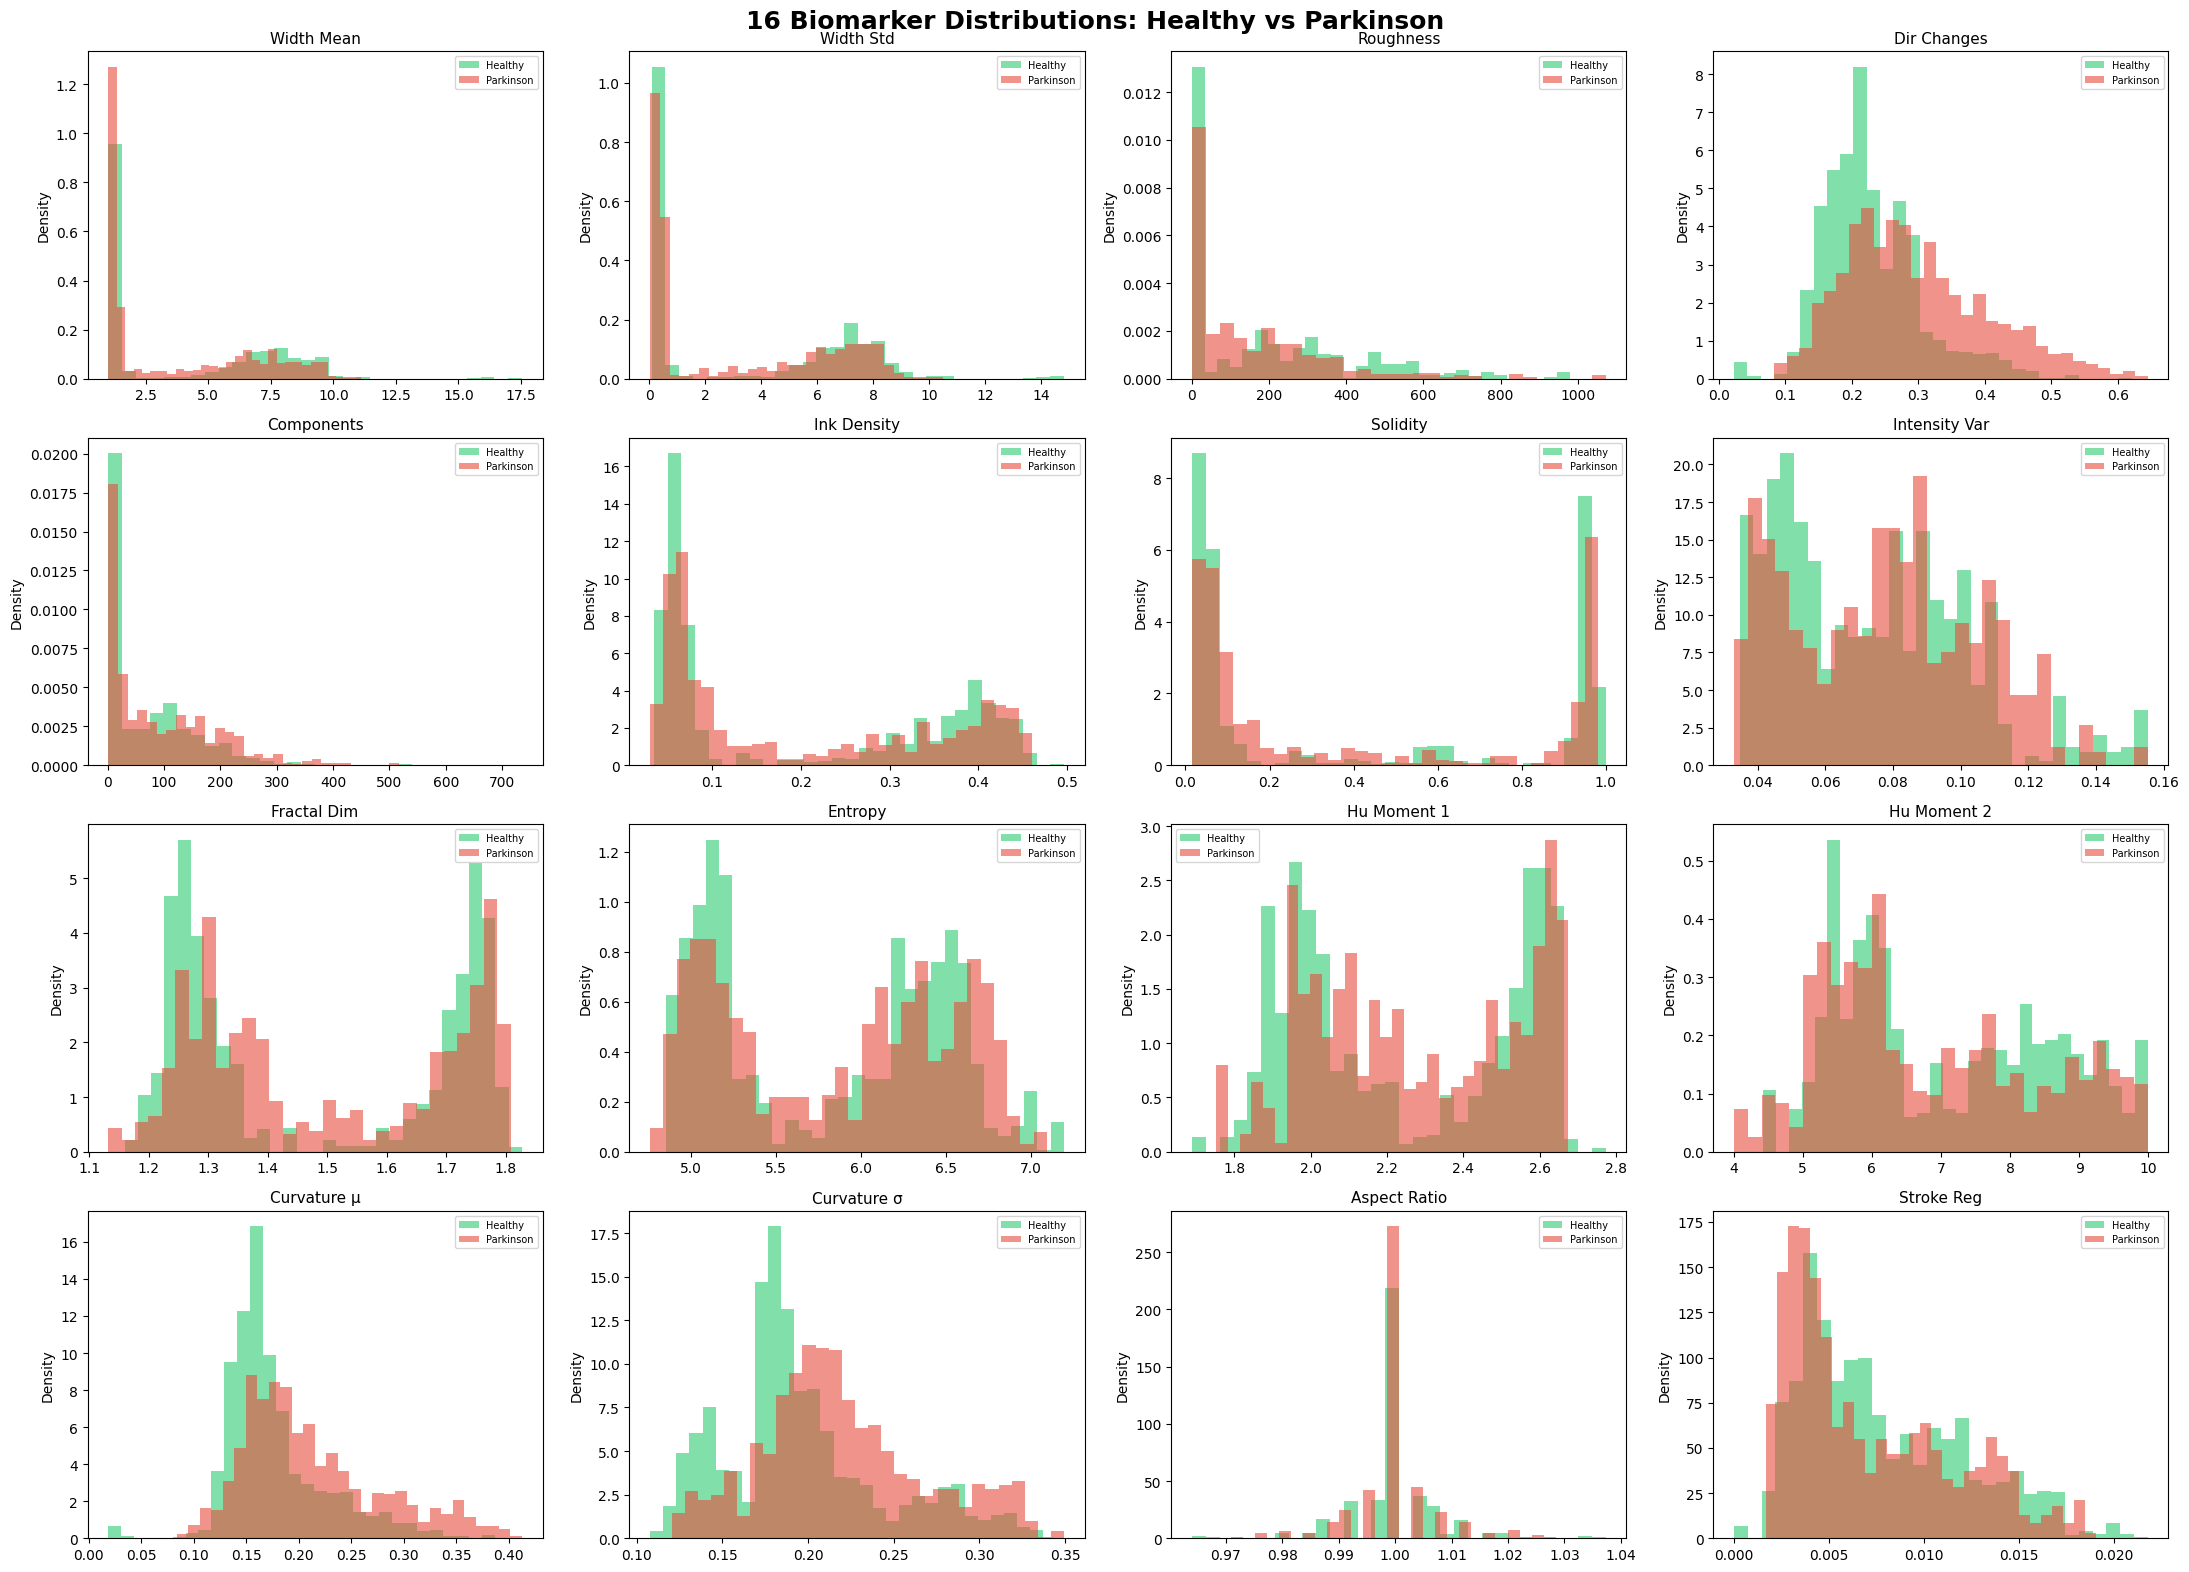

[✓] Saved feature_distributions.png


In [5]:
# Feature distribution comparison — 16 biomarkers
feature_names = [
    'Width Mean', 'Width Std', 'Roughness', 'Dir Changes',
    'Components', 'Ink Density', 'Solidity', 'Intensity Var',
    'Fractal Dim', 'Entropy', 'Hu Moment 1', 'Hu Moment 2',
    'Curvature μ', 'Curvature σ', 'Aspect Ratio', 'Stroke Reg'
]

fig, axes = plt.subplots(4, 4, figsize=(22, 16))
fig.suptitle('16 Biomarker Distributions: Healthy vs Parkinson', fontsize=18, fontweight='bold')

for i, (ax, name) in enumerate(zip(axes.flat, feature_names)):
    healthy_vals = features[labels == 0, i]
    pd_vals = features[labels == 1, i]

    ax.hist(healthy_vals, bins=30, alpha=0.6, label='Healthy', color='#2ecc71', density=True)
    ax.hist(pd_vals, bins=30, alpha=0.6, label='Parkinson', color='#e74c3c', density=True)
    ax.set_title(name, fontsize=11)
    ax.legend(fontsize=7)
    ax.set_ylabel('Density')

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("[✓] Saved feature_distributions.png")

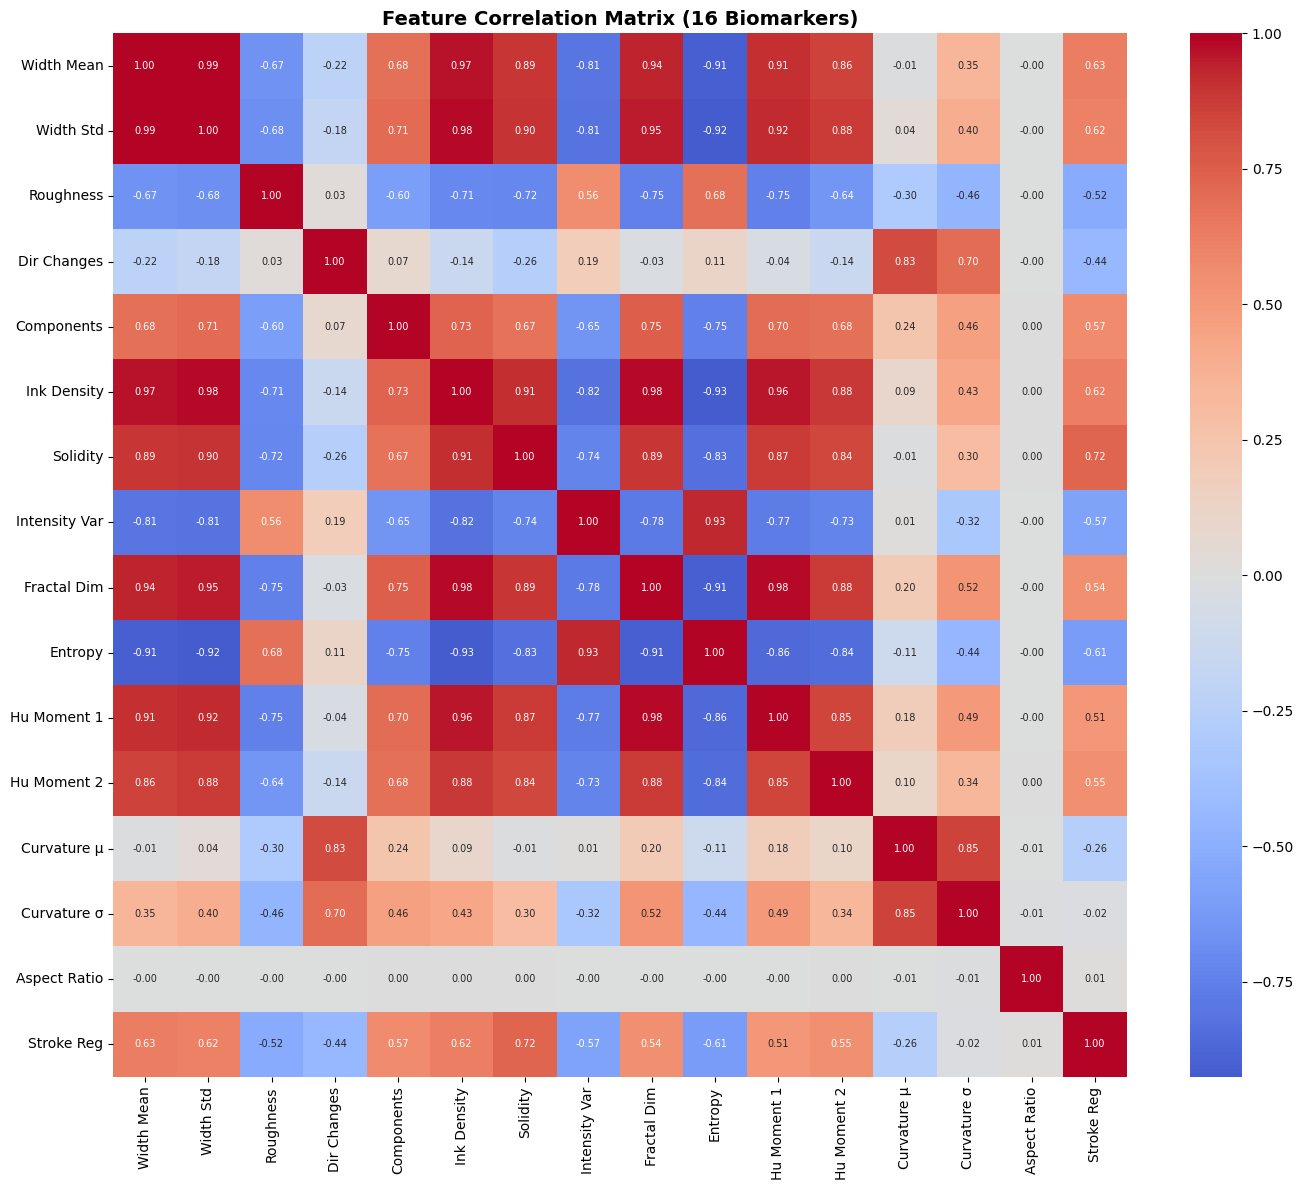

[✓] Saved correlation_matrix.png


In [6]:
# Correlation heatmap — 16 features
df = pd.DataFrame(features, columns=feature_names)
df['Label'] = ['Parkinson' if l == 1 else 'Healthy' for l in labels]

fig, ax = plt.subplots(figsize=(14, 12))
corr = df[feature_names].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            xticklabels=feature_names, yticklabels=feature_names, ax=ax,
            annot_kws={'size': 7})
ax.set_title('Feature Correlation Matrix (16 Biomarkers)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("[✓] Saved correlation_matrix.png")

In [7]:
# Summary statistics — 16 features
print("\n" + "=" * 80)
print("FEATURE STATISTICS (16 Biomarkers)")
print("=" * 80)
for i, name in enumerate(feature_names):
    h_mean = features[labels == 0, i].mean()
    h_std = features[labels == 0, i].std()
    p_mean = features[labels == 1, i].mean()
    p_std = features[labels == 1, i].std()
    diff = abs(h_mean - p_mean)
    pooled_std = np.sqrt((h_std**2 + p_std**2) / 2) + 1e-8
    effect_size = diff / pooled_std  # Cohen's d
    marker = "★" if effect_size > 0.5 else " "
    print(f"  {marker} {name:15s} | Healthy: {h_mean:.4f}±{h_std:.4f} | PD: {p_mean:.4f}±{p_std:.4f} | Δ={diff:.4f} | d={effect_size:.2f}")
print("=" * 80)
print("  ★ = Effect size (Cohen's d) > 0.5 — clinically meaningful difference")


FEATURE STATISTICS (16 Biomarkers)
    Width Mean      | Healthy: 4.1531±3.5405 | PD: 3.7141±3.0414 | Δ=0.4389 | d=0.13
    Width Std       | Healthy: 3.4360±3.6126 | PD: 3.0933±3.2107 | Δ=0.3426 | d=0.10
    Roughness       | Healthy: 197.7558±223.0966 | PD: 157.1138±186.3927 | Δ=40.6420 | d=0.20
  ★ Dir Changes     | Healthy: 0.2288±0.0744 | PD: 0.2965±0.1077 | Δ=0.0677 | d=0.73
    Components      | Healthy: 67.6042±80.5014 | PD: 94.6777±94.4168 | Δ=27.0735 | d=0.31
    Ink Density     | Healthy: 0.2005±0.1586 | PD: 0.1970±0.1499 | Δ=0.0034 | d=0.02
    Solidity        | Healthy: 0.4162±0.4197 | PD: 0.3897±0.3932 | Δ=0.0265 | d=0.07
    Intensity Var   | Healthy: 0.0737±0.0280 | PD: 0.0777±0.0273 | Δ=0.0040 | d=0.15
    Fractal Dim     | Healthy: 1.4811±0.2306 | PD: 1.4992±0.2121 | Δ=0.0182 | d=0.08
    Entropy         | Healthy: 5.8144±0.6767 | PD: 5.8581±0.6670 | Δ=0.0437 | d=0.07
    Hu Moment 1     | Healthy: 2.2486±0.2954 | PD: 2.2777±0.2664 | Δ=0.0291 | d=0.10
    Hu Moment 2

## Phase 4: Advanced Model Architectures

### Approach 1: Residual MLP (16 biomarkers → Residual blocks → prediction)
- Skip connections for better gradient flow
- Batch normalization + Dropout regularization
- Label smoothing + Focal Loss for class imbalance

### Approach 2: EfficientNet-B0 + CBAM Attention
- EfficientNet-B0 (smaller but optimal for this dataset size)
- CBAM: Channel Attention + Spatial Attention modules
- Cosine Annealing + SWA (Stochastic Weight Averaging)

In [8]:
class HandwritingDataset(Dataset):
    """PyTorch Dataset for handwriting biomarker features"""
    def __init__(self, features, labels):
        self.features = torch.FloatTensor(features)
        self.labels = torch.FloatTensor(labels)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]


class ResidualBlock(nn.Module):
    """Residual block with skip connection for better gradient flow."""
    def __init__(self, dim, dropout=0.4):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
        )
        self.act = nn.GELU()
        self.dropout = nn.Dropout(dropout * 0.5)

    def forward(self, x):
        return self.dropout(self.act(self.block(x) + x))


class PDDetectionModelV2(nn.Module):
    """Residual MLP for PD detection from 16 biomarkers.
    
    Architecture: 16 → 64 → [ResBlock×1] → 32 → 1
    Reduced capacity vs original to prevent overfitting on small dataset.
    """
    def __init__(self, input_size=16, hidden=64):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_size, hidden),
            nn.BatchNorm1d(hidden),
            nn.GELU(),
            nn.Dropout(0.3),
        )
        self.res1 = ResidualBlock(hidden, dropout=0.4)
        self.head = nn.Sequential(
            nn.Linear(hidden, 32),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.Dropout(0.35),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = self.res1(x)
        return torch.sigmoid(self.head(x))


class FocalLoss(nn.Module):
    """Focal Loss with label smoothing for class imbalance."""
    def __init__(self, alpha=0.25, gamma=2.0, label_smoothing=0.05):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.smoothing = label_smoothing

    def forward(self, inputs, targets):
        # Apply label smoothing
        targets_smooth = targets * (1 - self.smoothing) + 0.5 * self.smoothing
        bce = F.binary_cross_entropy(inputs, targets_smooth, reduction='none')
        pt = torch.exp(-bce)
        return (self.alpha * (1 - pt) ** self.gamma * bce).mean()


# Quick architecture test
test_model = PDDetectionModelV2().to(device)
test_input = torch.randn(4, 16).to(device)
test_output = test_model(test_input)
print(f"[✓] Residual MLP test: input {test_input.shape} -> output {test_output.shape}")
print(f"    Parameters: {sum(p.numel() for p in test_model.parameters()):,}")
del test_model, test_input, test_output

[✓] Residual MLP test: input torch.Size([4, 16]) -> output torch.Size([4, 1])
    Parameters: 11,969


## Phase 5: Training with 5-Fold CV + LIVE Training Dashboard

The live dashboard updates **every epoch** showing:
- 📈 Train/Val Loss curves
- 📊 Accuracy & AUC-ROC progress per fold
- 🎯 Best scores tracker
- 🔄 Real-time predictions on sample images

In [9]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    for feats, labs in loader:
        feats, labs = feats.to(device), labs.to(device).unsqueeze(1)
        optimizer.zero_grad()
        loss = criterion(model(feats), labs)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for feats, labs in loader:
            feats, labs = feats.to(device), labs.to(device).unsqueeze(1)
            outputs = model(feats)
            total_loss += criterion(outputs, labs).item()
            all_preds.extend(outputs.cpu().numpy().flatten())
            all_labels.extend(labs.cpu().numpy().flatten())

    preds = np.array(all_preds)
    labels_arr = np.array(all_labels)
    binary_preds = (preds > 0.5).astype(int)
    binary_labels = (labels_arr > 0.5).astype(int)
    acc = accuracy_score(binary_labels, binary_preds)
    auc = roc_auc_score(binary_labels, preds) if len(np.unique(binary_labels)) > 1 else 0.0
    return total_loss / len(loader), acc, auc, preds, labels_arr


class LiveTrainingDashboard:
    """Real-time training visualization that updates every epoch."""
    
    def __init__(self, n_folds, title="Training Dashboard"):
        self.n_folds = n_folds
        self.title = title
        self.colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
        self.fold_data = {}
        self.fig = None
        self.axes = None
        self.output = None
    
    def init_display(self):
        """Create the output widget for live updates."""
        self.output = display(HTML(f"<h3>🔄 {self.title} — Initializing...</h3>"), display_id=True)
    
    def start_fold(self, fold_idx):
        """Initialize tracking for a new fold."""
        self.fold_data[fold_idx] = {
            'train_loss': [], 'val_loss': [],
            'val_acc': [], 'val_auc': [],
            'best_auc': 0.0, 'best_acc': 0.0
        }
    
    def update(self, fold_idx, epoch, train_loss, val_loss, val_acc, val_auc):
        """Update the live dashboard with new epoch data."""
        d = self.fold_data[fold_idx]
        d['train_loss'].append(train_loss)
        d['val_loss'].append(val_loss)
        d['val_acc'].append(val_acc)
        d['val_auc'].append(val_auc)
        d['best_auc'] = max(d['best_auc'], val_auc)
        d['best_acc'] = max(d['best_acc'], val_acc)
        
        # Redraw every 5 epochs or at start/end
        if epoch % 5 == 0 or epoch <= 2:
            self._redraw(fold_idx, epoch)
    
    def _redraw(self, current_fold, current_epoch):
        """Redraw the full dashboard."""
        fig, axes = plt.subplots(2, 2, figsize=(14, 9))
        fig.suptitle(f'{self.title} — Fold {current_fold+1}/{self.n_folds}, Epoch {current_epoch+1}',
                     fontsize=14, fontweight='bold')
        
        for fold_idx, data in self.fold_data.items():
            c = self.colors[fold_idx % len(self.colors)]
            lw = 2.5 if fold_idx == current_fold else 1.0
            alpha = 1.0 if fold_idx == current_fold else 0.4
            label = f'Fold {fold_idx+1}'
            
            axes[0, 0].plot(data['train_loss'], color=c, linewidth=lw, alpha=alpha, label=label)
            axes[0, 1].plot(data['val_loss'], color=c, linewidth=lw, alpha=alpha, label=label)
            axes[1, 0].plot(data['val_acc'], color=c, linewidth=lw, alpha=alpha, label=label)
            axes[1, 1].plot(data['val_auc'], color=c, linewidth=lw, alpha=alpha, label=label)
        
        titles = ['Train Loss ↓', 'Val Loss ↓', 'Val Accuracy ↑', 'Val AUC-ROC ↑']
        for ax, title in zip(axes.flat, titles):
            ax.set_title(title, fontsize=11, fontweight='bold')
            ax.set_xlabel('Epoch')
            ax.legend(fontsize=7, loc='best')
            ax.grid(True, alpha=0.3)
        
        # Add best scores text
        best_info = []
        for fold_idx, data in self.fold_data.items():
            best_info.append(f"F{fold_idx+1}: AUC={data['best_auc']:.4f} Acc={data['best_acc']:.4f}")
        fig.text(0.5, 0.01, ' | '.join(best_info), ha='center', fontsize=9,
                 style='italic', color='#555')
        
        plt.tight_layout(rect=[0, 0.03, 1, 0.96])
        
        # Update display in-place
        if self.output is not None:
            self.output.update(fig)
        plt.close(fig)


print("[✓] Training functions + Live Dashboard ready")

[✓] Training functions + Live Dashboard ready


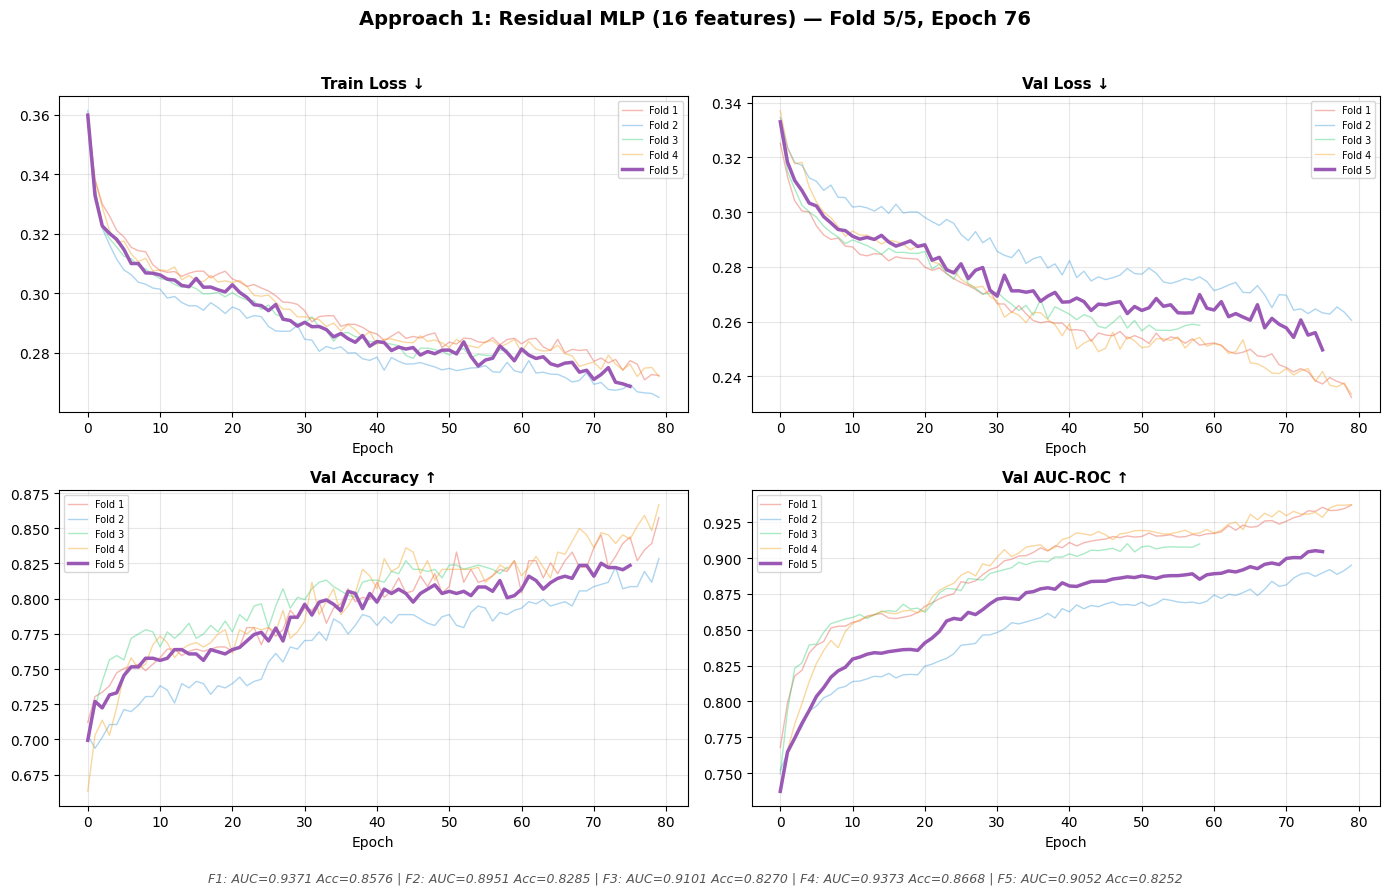


APPROACH 1: Residual MLP with 16 Biomarkers — 5-Fold CV
Samples: 3264 | Features: 16 | Device: cuda
Epochs: 80 | Batch: 64 | LR: 0.0003 | Patience: 10
Augmentation: 2x noise + Mixup (inside each fold)

────────────────────────────────────────────────────────────
FOLD 1/5
────────────────────────────────────────────────────────────
  Train: 8485 (2611 orig + 5874 aug+mixup)
  Val:   653 [no augmentation]
  Epoch  25 | Loss: 0.3018/0.2757 | Acc: 0.7672 | AUC: 0.8752
  Epoch  50 | Loss: 0.2818/0.2548 | Acc: 0.8040 | AUC: 0.9147
  Epoch  75 | Loss: 0.2742/0.2384 | Acc: 0.8392 | AUC: 0.9326

  ✓ Fold 1 Best: Acc=0.8576 | Bal.Acc=0.8576 | AUC=0.9371

────────────────────────────────────────────────────────────
FOLD 2/5
────────────────────────────────────────────────────────────
  Train: 8485 (2611 orig + 5874 aug+mixup)
  Val:   653 [no augmentation]
  Epoch  25 | Loss: 0.2922/0.2959 | Acc: 0.7427 | AUC: 0.8333
  Epoch  50 | Loss: 0.2743/0.2775 | Acc: 0.7871 | AUC: 0.8669
  Epoch  75 | Los

In [10]:
# ===== HYPERPARAMETERS =====
N_FOLDS = 5
EPOCHS = 80
BATCH_SIZE = 64
LEARNING_RATE = 3e-4
PATIENCE = 10
N_AUG = 2  # reduced from 5 to prevent overfitting from near-duplicate samples

# NOTE: Scaler is now fitted per-fold inside the training loop to avoid data leakage.
# A final scaler fitted on all data is saved after training for deployment inference.

def combined_loss(out, tgt):
    """Combined BCE + Focal Loss with label smoothing."""
    smooth_tgt = tgt * 0.90 + 0.05  # stronger label smoothing to prevent overconfidence
    bce = F.binary_cross_entropy(out, smooth_tgt)
    # Focal component
    bce_unreduced = F.binary_cross_entropy(out, smooth_tgt, reduction='none')
    pt = torch.exp(-bce_unreduced)
    focal = (0.25 * (1 - pt) ** 2.0 * bce_unreduced).mean()
    return 0.5 * bce + 0.5 * focal

kfold = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

fold_models = []
fold_histories = []
all_fold_preds = []
all_fold_labels = []

# ===== LIVE TRAINING DASHBOARD =====
dashboard = LiveTrainingDashboard(N_FOLDS, title="Approach 1: Residual MLP (16 features)")
dashboard.init_display()

print(f"\n{'=' * 80}")
print(f"APPROACH 1: Residual MLP with 16 Biomarkers — {N_FOLDS}-Fold CV")
print(f"{'=' * 80}")
print(f"Samples: {len(features)} | Features: {features.shape[1]} | Device: {device}")
print(f"Epochs: {EPOCHS} | Batch: {BATCH_SIZE} | LR: {LEARNING_RATE} | Patience: {PATIENCE}")
print(f"Augmentation: {N_AUG}x noise + Mixup (inside each fold)")

for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(features, labels)):
    print(f"\n{'─' * 60}")
    print(f"FOLD {fold_idx + 1}/{N_FOLDS}")
    print(f"{'─' * 60}")

    # Fit scaler on TRAINING data only (no leakage)
    fold_scaler = StandardScaler()
    train_feats_scaled = fold_scaler.fit_transform(features[train_idx])
    val_feats_scaled = fold_scaler.transform(features[val_idx])

    train_feats_aug, train_labels_aug = augment_features(train_feats_scaled, labels[train_idx], n_aug=N_AUG)

    val_feats = val_feats_scaled
    val_labels_arr = labels[val_idx]

    print(f"  Train: {len(train_feats_aug)} ({len(train_idx)} orig + {len(train_feats_aug)-len(train_idx)} aug+mixup)")
    print(f"  Val:   {len(val_feats)} [no augmentation]")

    train_ds = HandwritingDataset(train_feats_aug, train_labels_aug)
    val_ds = HandwritingDataset(val_feats, val_labels_arr)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

    model = PDDetectionModelV2(input_size=16).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=5e-3)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=20, T_mult=2)

    best_auc = 0.0
    patience_counter = 0
    best_state = None
    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_auc': []}
    dashboard.start_fold(fold_idx)

    for epoch in range(EPOCHS):
        train_loss = train_epoch(model, train_loader, combined_loss, optimizer, device)
        val_loss, val_acc, val_auc, _, _ = evaluate(model, val_loader, combined_loss, device)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_auc'].append(val_auc)
        
        # ===== LIVE DASHBOARD UPDATE =====
        dashboard.update(fold_idx, epoch, train_loss, val_loss, val_acc, val_auc)

        if (epoch + 1) % 25 == 0:
            print(f"  Epoch {epoch+1:3d} | Loss: {train_loss:.4f}/{val_loss:.4f} | "
                  f"Acc: {val_acc:.4f} | AUC: {val_auc:.4f}")

        if val_auc > best_auc:
            best_auc = val_auc
            patience_counter = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    model.load_state_dict(best_state)
    model.to(device)
    _, final_acc, final_auc, preds, true_labs = evaluate(model, val_loader, combined_loss, device)
    bal_acc = balanced_accuracy_score((true_labs > 0.5).astype(int), (preds > 0.5).astype(int))

    print(f"\n  ✓ Fold {fold_idx+1} Best: Acc={final_acc:.4f} | Bal.Acc={bal_acc:.4f} | AUC={final_auc:.4f}")

    fold_models.append(model)
    fold_histories.append(history)
    all_fold_preds.append(preds)
    all_fold_labels.append(true_labs)

# Fit final scaler on ALL data for deployment inference
scaler = StandardScaler()
features_normalized = scaler.fit_transform(features)

print(f"\n{'=' * 80}")
print("MLP TRAINING COMPLETE — Check live dashboard above for training curves!")
print(f"{'=' * 80}")

## Phase 6: Results & Evaluation

In [11]:
# Aggregate cross-validation results (MLP)
all_preds_flat = np.concatenate(all_fold_preds)
all_labels_flat = np.concatenate(all_fold_labels)

# Handle mixed labels from mixup (binarize)
binary_labels_flat = (all_labels_flat > 0.5).astype(int)
pred_binary = (all_preds_flat > 0.5).astype(int)

overall_acc = accuracy_score(binary_labels_flat, pred_binary)
overall_bal_acc = balanced_accuracy_score(binary_labels_flat, pred_binary)
overall_auc = roc_auc_score(binary_labels_flat, all_preds_flat)
overall_f1 = f1_score(binary_labels_flat, pred_binary)

print("=" * 60)
print("RESIDUAL MLP CROSS-VALIDATION RESULTS (5-Fold)")
print("=" * 60)
print(f"  Overall Accuracy:          {overall_acc:.4f}")
print(f"  Overall Balanced Accuracy: {overall_bal_acc:.4f}")
print(f"  Overall AUC-ROC:           {overall_auc:.4f}")
print(f"  Overall F1-Score:          {overall_f1:.4f}")
print("=" * 60)

print("\nClassification Report:")
print(classification_report(binary_labels_flat, pred_binary,
                            target_names=['Healthy', 'Parkinson']))

RESIDUAL MLP CROSS-VALIDATION RESULTS (5-Fold)
  Overall Accuracy:          0.8398
  Overall Balanced Accuracy: 0.8398
  Overall AUC-ROC:           0.9158
  Overall F1-Score:          0.8333

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.82      0.88      0.85      1632
   Parkinson       0.87      0.80      0.83      1632

    accuracy                           0.84      3264
   macro avg       0.84      0.84      0.84      3264
weighted avg       0.84      0.84      0.84      3264



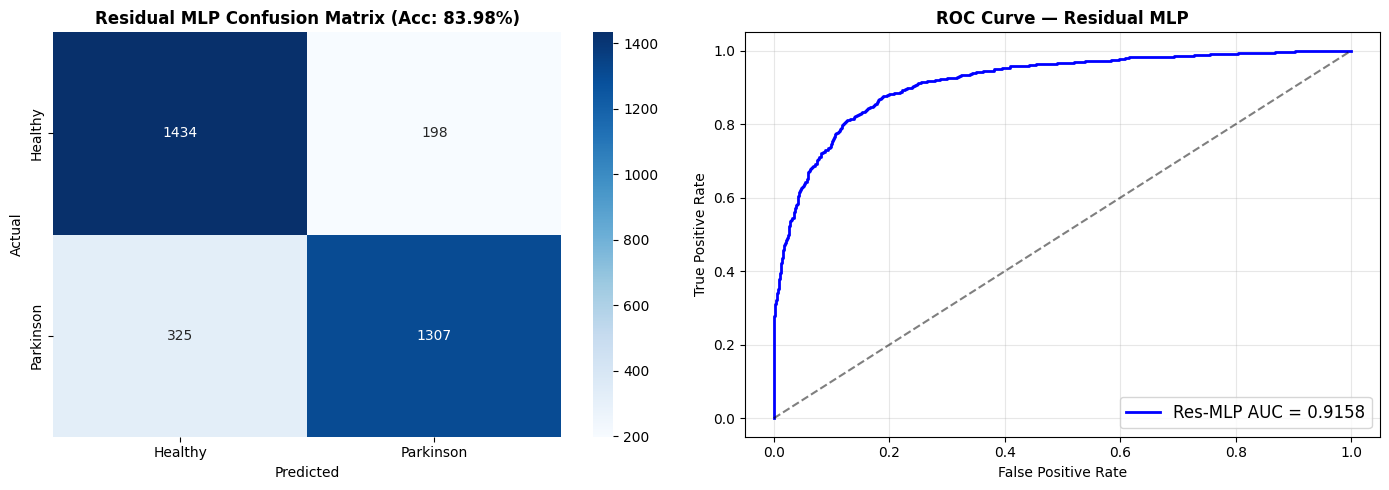

[✓] Saved evaluation_results.png


In [12]:
# Confusion Matrix + ROC (MLP)
cm = confusion_matrix(binary_labels_flat, pred_binary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Healthy', 'Parkinson'],
            yticklabels=['Healthy', 'Parkinson'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'Residual MLP Confusion Matrix (Acc: {overall_acc:.2%})', fontweight='bold')

fpr, tpr, _ = roc_curve(binary_labels_flat, all_preds_flat)
axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'Res-MLP AUC = {overall_auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Residual MLP', fontweight='bold')
axes[1].legend(loc='lower right', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("[✓] Saved evaluation_results.png")

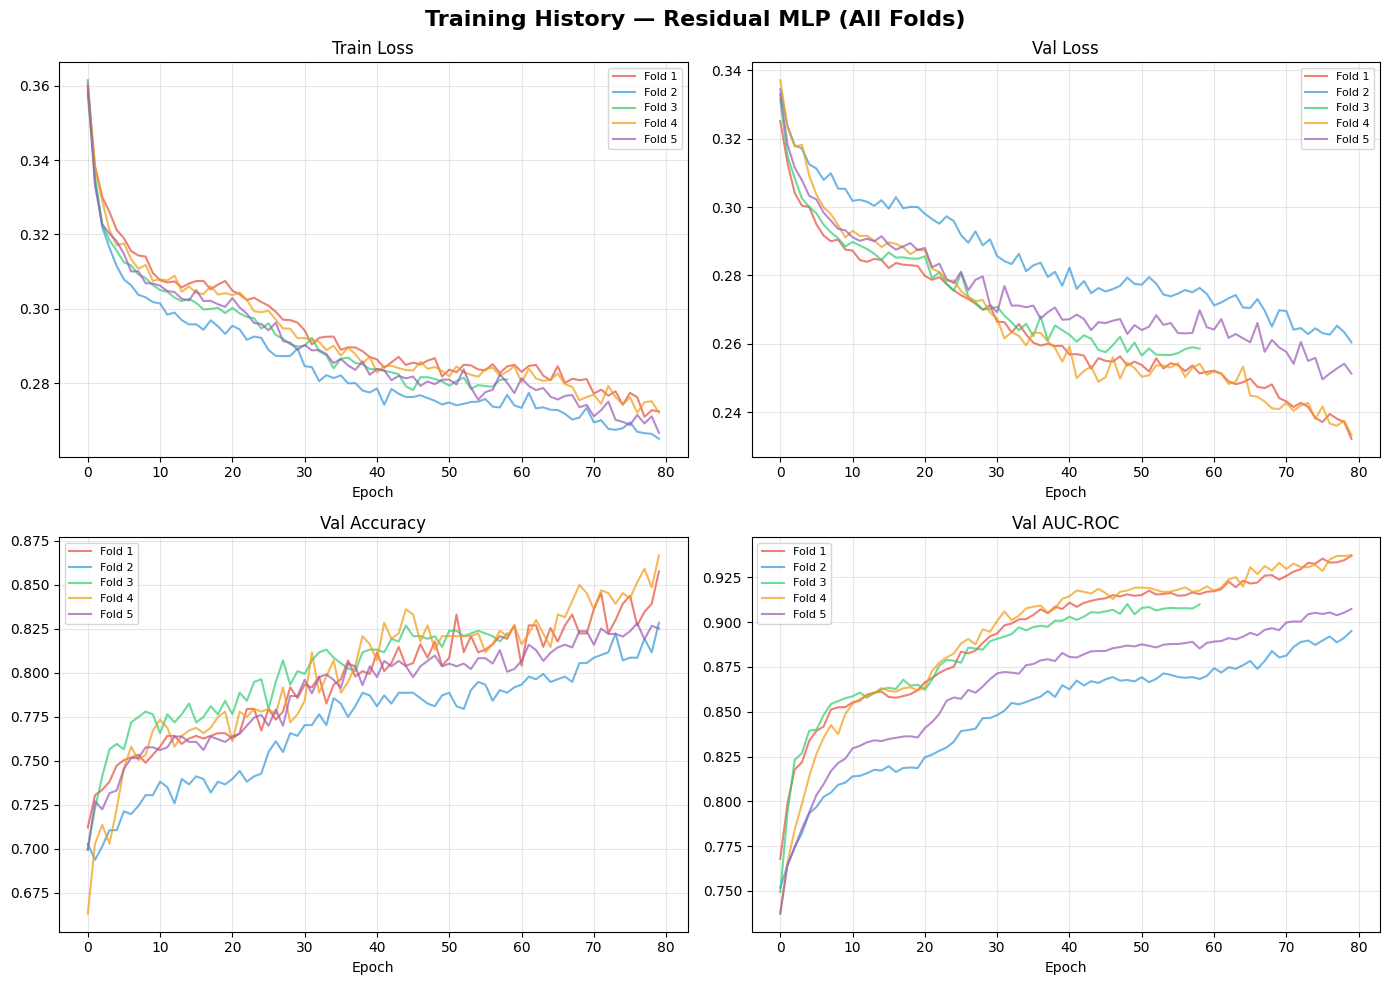

[✓] Saved training_history.png


In [13]:
# Training history plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training History — Residual MLP (All Folds)', fontsize=16, fontweight='bold')

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

for fold_idx, hist in enumerate(fold_histories):
    c = colors[fold_idx]
    axes[0, 0].plot(hist['train_loss'], color=c, alpha=0.7, label=f'Fold {fold_idx+1}')
    axes[0, 1].plot(hist['val_loss'], color=c, alpha=0.7, label=f'Fold {fold_idx+1}')
    axes[1, 0].plot(hist['val_acc'], color=c, alpha=0.7, label=f'Fold {fold_idx+1}')
    axes[1, 1].plot(hist['val_auc'], color=c, alpha=0.7, label=f'Fold {fold_idx+1}')

for ax, title in zip(axes.flat, ['Train Loss', 'Val Loss', 'Val Accuracy', 'Val AUC-ROC']):
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("[✓] Saved training_history.png")

APPROACH 2: EfficientNet-B0 + CBAM Attention
Images: 3264 (Healthy: 1632, PD: 1632)


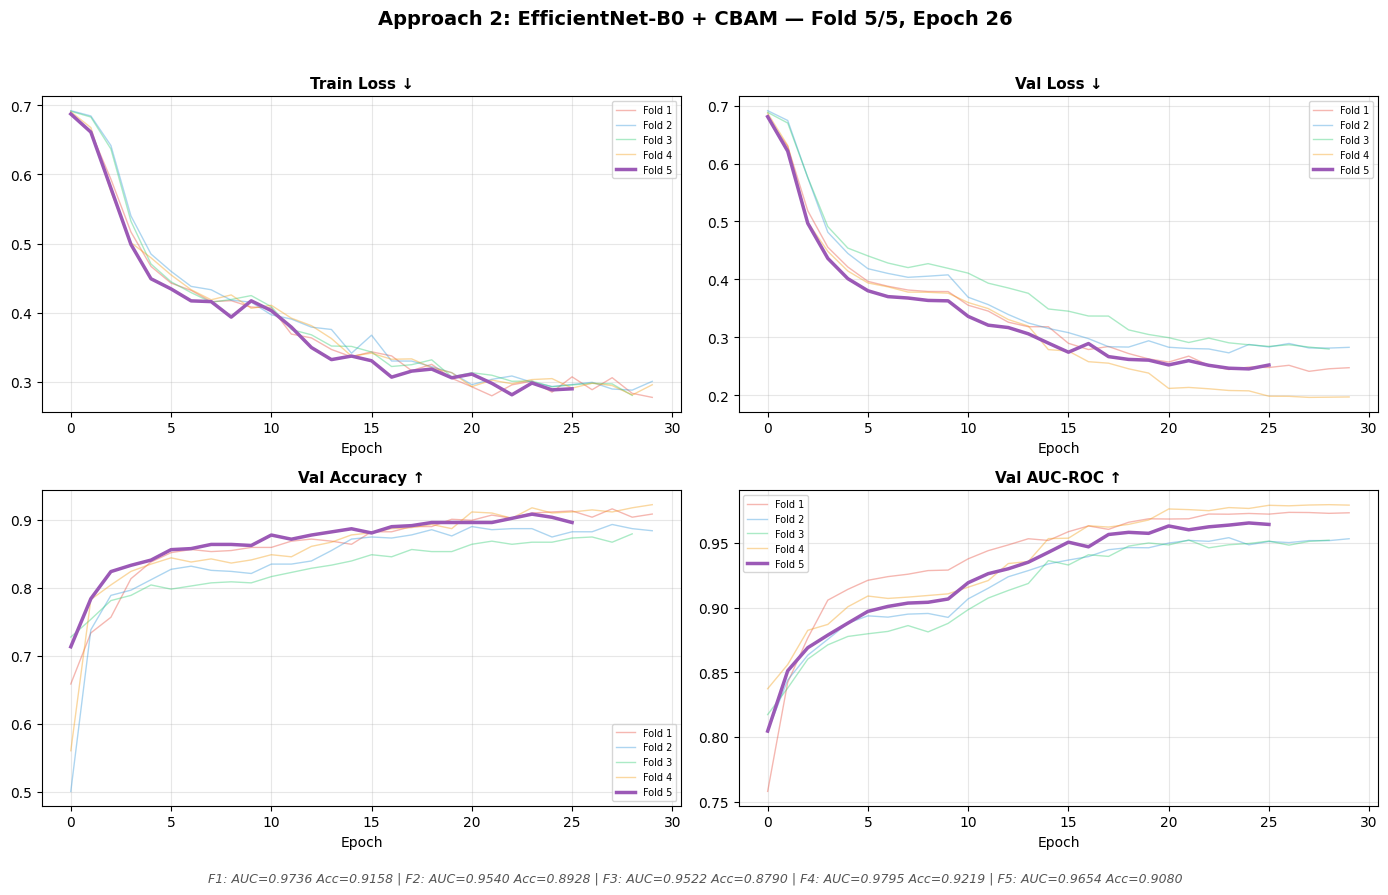


GPU Optimization: batch_size=64, num_workers=2, AMP=True, pin_memory=True

────────────────────────────────────────────────────────────
CNN FOLD 1/5 (Train: 2611, Val: 653)
────────────────────────────────────────────────────────────
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 168MB/s]


  Epoch 10 | Acc: 0.8591 | AUC: 0.9290
  Epoch 20 | Acc: 0.9005 | AUC: 0.9686
  Epoch 30 | Acc: 0.9081 | AUC: 0.9733
  ✓ CNN Fold 1 | AUC: 0.9736 | Acc: 0.9035 | Acc(TTA): 0.9433 | F1: 0.9067

────────────────────────────────────────────────────────────
CNN FOLD 2/5 (Train: 2611, Val: 653)
────────────────────────────────────────────────────────────
  Epoch 10 | Acc: 0.8208 | AUC: 0.8924
  Epoch 20 | Acc: 0.8760 | AUC: 0.9462
  Epoch 30 | Acc: 0.8836 | AUC: 0.9532
  ✓ CNN Fold 2 | AUC: 0.9540 | Acc: 0.8867 | Acc(TTA): 0.9173 | F1: 0.8854

────────────────────────────────────────────────────────────
CNN FOLD 3/5 (Train: 2611, Val: 653)
────────────────────────────────────────────────────────────
  Epoch 10 | Acc: 0.8070 | AUC: 0.8878
  Epoch 20 | Acc: 0.8530 | AUC: 0.9499
  Early stop at epoch 29
  ✓ CNN Fold 3 | AUC: 0.9522 | Acc: 0.8683 | Acc(TTA): 0.8851 | F1: 0.8613

────────────────────────────────────────────────────────────
CNN FOLD 4/5 (Train: 2611, Val: 653)
───────────────────

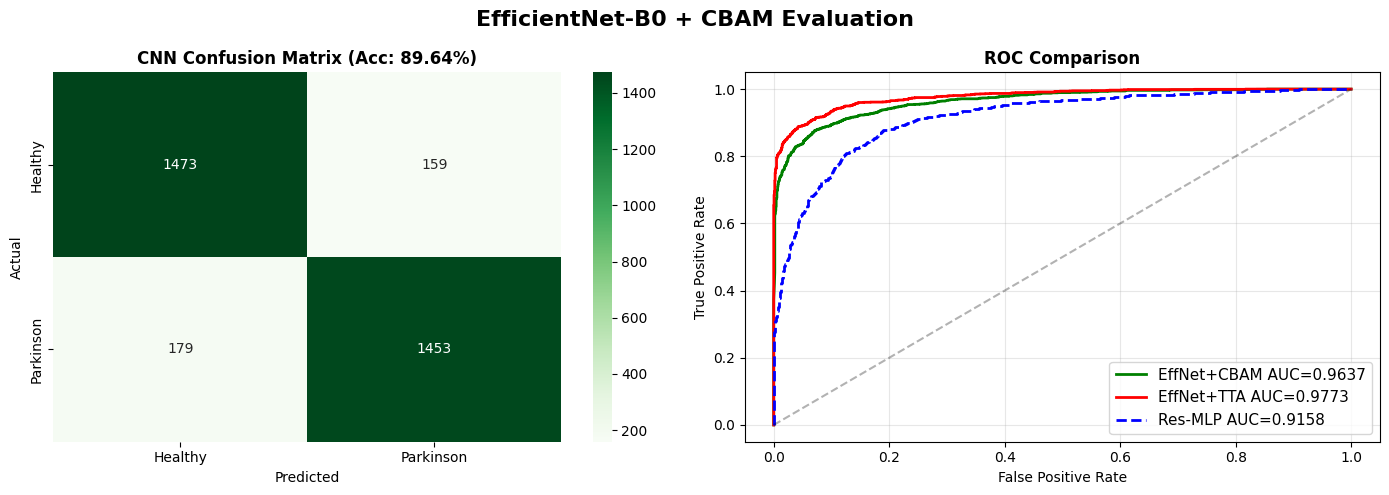

[✓] Saved cnn_evaluation.png


In [14]:
# =====================================================================
# APPROACH 2: EfficientNet-B0 + CBAM Attention Module
# =====================================================================
# Improvements over basic ResNet-18:
#   1. EfficientNet-B0: optimal width/depth/resolution scaling
#   2. CBAM: Channel + Spatial attention for focusing on tremor regions
#   3. Cosine Annealing Warm Restarts + gradient clipping
#   4. Advanced augmentation: RandomErasing, stronger geometric transforms
#   5. TTA with 7 views (up from 5)
#   6. Mixed Precision (AMP) for faster GPU utilization
# =====================================================================

from torch.amp import autocast, GradScaler

print("=" * 80)
print("APPROACH 2: EfficientNet-B0 + CBAM Attention")
print("=" * 80)

img_paths = np.array(img_path_list)
img_labels = labels.copy()
print(f"Images: {len(img_paths)} (Healthy: {sum(img_labels==0)}, PD: {sum(img_labels==1)})")


class ChannelAttention(nn.Module):
    """CBAM Channel Attention Module."""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        avg_pool = F.adaptive_avg_pool2d(x, 1).view(b, c)
        max_pool = F.adaptive_max_pool2d(x, 1).view(b, c)
        attn = torch.sigmoid(self.fc(avg_pool) + self.fc(max_pool))
        return x * attn.view(b, c, 1, 1)


class SpatialAttention(nn.Module):
    """CBAM Spatial Attention Module."""
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)

    def forward(self, x):
        avg_pool = torch.mean(x, dim=1, keepdim=True)
        max_pool = torch.max(x, dim=1, keepdim=True)[0]
        combined = torch.cat([avg_pool, max_pool], dim=1)
        attn = torch.sigmoid(self.conv(combined))
        return x * attn


class CBAM(nn.Module):
    """Convolutional Block Attention Module (Channel + Spatial)."""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.channel_attn = ChannelAttention(channels, reduction)
        self.spatial_attn = SpatialAttention()

    def forward(self, x):
        x = self.channel_attn(x)
        x = self.spatial_attn(x)
        return x


class ImageDataset(Dataset):
    """PyTorch Dataset that loads images for CNN training."""
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = torch.FloatTensor(labels)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


# Advanced data transforms
train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),
])
val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# TTA: 7 augmented views per image
tta_transforms = [
    val_tf,
    transforms.Compose([transforms.Resize((224, 224)), transforms.RandomHorizontalFlip(p=1.0),
                         transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
    transforms.Compose([transforms.Resize((224, 224)), transforms.RandomRotation((10, 10)),
                         transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
    transforms.Compose([transforms.Resize((224, 224)), transforms.RandomRotation((-10, -10)),
                         transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
    transforms.Compose([transforms.Resize((224, 224)), transforms.ColorJitter(brightness=0.3),
                         transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
    transforms.Compose([transforms.Resize((224, 224)), transforms.RandomVerticalFlip(p=1.0),
                         transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
    transforms.Compose([transforms.Resize((256, 256)), transforms.CenterCrop(224),
                         transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
]


def create_efficientnet_cbam():
    """EfficientNet-B0 + CBAM attention for PD handwriting classification."""
    try:
        backbone = models.efficientnet_b0(weights='IMAGENET1K_V1')
    except TypeError:
        backbone = models.efficientnet_b0(pretrained=True)
    
    # Freeze early layers (first 80%), fine-tune only final layers to prevent overfitting
    all_params = list(backbone.parameters())
    freeze_until = int(len(all_params) * 0.8)
    for param in all_params[:freeze_until]:
        param.requires_grad = False
    
    # Get the feature dimension
    feat_dim = backbone.classifier[1].in_features  # 1280 for B0
    backbone.classifier = nn.Identity()
    
    # Add CBAM on top of features
    cbam = CBAM(1280, reduction=16)
    
    class EfficientNetCBAM(nn.Module):
        def __init__(self, backbone, cbam, feat_dim):
            super().__init__()
            self.backbone = backbone
            self.cbam = cbam
            self.pool = nn.AdaptiveAvgPool2d(1)
            self.classifier = nn.Sequential(
                nn.Dropout(0.5),
                nn.Linear(feat_dim, 128),
                nn.GELU(),
                nn.Dropout(0.4),
                nn.Linear(128, 1),
            )
        
        def forward(self, x):
            # Get features before pooling
            x = self.backbone.features(x)
            x = self.cbam(x)
            x = self.pool(x)
            x = x.flatten(1)
            return self.classifier(x)
    
    return EfficientNetCBAM(backbone, cbam, feat_dim)


def predict_with_tta(model, img_path, device, tta_tfs):
    """Test-Time Augmentation: average predictions over 7 views."""
    img = Image.open(img_path).convert('RGB')
    preds = []
    with torch.no_grad():
        for tf in tta_tfs:
            inp = tf(img).unsqueeze(0).to(device)
            with autocast(device_type='cuda', enabled=torch.cuda.is_available()):
                preds.append(torch.sigmoid(model(inp)).cpu().item())
    return float(np.mean(preds))


# ===== 5-Fold CV for EfficientNet-B0 + CBAM =====
CNN_EPOCHS = 30
CNN_BATCH_SIZE = 64  # Increased from 16 — P100 (16GB) can handle this easily
CNN_PATIENCE = 7
NUM_WORKERS = 2  # Parallel data loading to keep GPU fed
cnn_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cnn_preds_all, cnn_labels_all = [], []
cnn_preds_tta_all = []
cnn_models = []

# Mixed precision scaler for faster training
amp_scaler = GradScaler('cuda', enabled=torch.cuda.is_available())

# Live dashboard for CNN training
cnn_dashboard = LiveTrainingDashboard(5, title="Approach 2: EfficientNet-B0 + CBAM")
cnn_dashboard.init_display()

print(f"\nGPU Optimization: batch_size={CNN_BATCH_SIZE}, num_workers={NUM_WORKERS}, AMP=True, pin_memory=True")

for fold_idx, (tr_idx, vl_idx) in enumerate(cnn_kfold.split(img_paths, img_labels)):
    print(f"\n{'─' * 60}")
    print(f"CNN FOLD {fold_idx+1}/5 (Train: {len(tr_idx)}, Val: {len(vl_idx)})")
    print(f"{'─' * 60}")

    tr_ds = ImageDataset(img_paths[tr_idx], img_labels[tr_idx], train_tf)
    vl_ds = ImageDataset(img_paths[vl_idx], img_labels[vl_idx], val_tf)
    tr_loader = DataLoader(tr_ds, batch_size=CNN_BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
    vl_loader = DataLoader(vl_ds, batch_size=CNN_BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)

    cnn = create_efficientnet_cbam().to(device)
    opt = optim.AdamW(filter(lambda p: p.requires_grad, cnn.parameters()),
                      lr=5e-5, weight_decay=5e-3)
    sched = optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=10, T_mult=2)
    crit = nn.BCEWithLogitsLoss()  # Use logits version for AMP compatibility
    best_auc, best_st, pat = 0.0, None, 0
    cnn_dashboard.start_fold(fold_idx)

    for ep in range(CNN_EPOCHS):
        # Train with AMP
        cnn.train()
        ep_loss = 0.0
        for imgs, labs in tr_loader:
            imgs, labs = imgs.to(device, non_blocking=True), labs.to(device, non_blocking=True).unsqueeze(1)
            opt.zero_grad(set_to_none=True)
            
            with autocast(device_type='cuda', enabled=torch.cuda.is_available()):
                logits = cnn(imgs)
                loss = crit(logits, labs)
            
            amp_scaler.scale(loss).backward()
            amp_scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(cnn.parameters(), max_norm=1.0)
            amp_scaler.step(opt)
            amp_scaler.update()
            ep_loss += loss.item()
        sched.step()
        train_loss = ep_loss / len(tr_loader)

        # Evaluate with AMP
        cnn.eval()
        vp, vl_list = [], []
        val_loss_sum = 0.0
        with torch.no_grad():
            for imgs, labs in vl_loader:
                imgs = imgs.to(device, non_blocking=True)
                labs_dev = labs.to(device, non_blocking=True).unsqueeze(1)
                with autocast(device_type='cuda', enabled=torch.cuda.is_available()):
                    logits = cnn(imgs)
                    val_loss_sum += crit(logits, labs_dev).item()
                probs = torch.sigmoid(logits)
                vp.extend(probs.cpu().numpy().flatten())
                vl_list.extend(labs.numpy())

        vauc = roc_auc_score(vl_list, vp) if len(set(vl_list)) > 1 else 0.0
        vacc = accuracy_score(vl_list, (np.array(vp) > 0.5).astype(int))
        val_loss = val_loss_sum / len(vl_loader)
        
        # ===== LIVE DASHBOARD UPDATE =====
        cnn_dashboard.update(fold_idx, ep, train_loss, val_loss, vacc, vauc)

        if vauc > best_auc:
            best_auc = vauc
            best_st = {k: v.cpu().clone() for k, v in cnn.state_dict().items()}
            pat = 0
        else:
            pat += 1
        if pat >= CNN_PATIENCE:
            print(f"  Early stop at epoch {ep+1}")
            break
        if (ep + 1) % 10 == 0:
            print(f"  Epoch {ep+1:2d} | Acc: {vacc:.4f} | AUC: {vauc:.4f}")

    cnn.load_state_dict(best_st)
    cnn.to(device).eval()

    # Final evaluation (standard)
    vp, vl_list = [], []
    with torch.no_grad():
        for imgs, labs in vl_loader:
            with autocast(device_type='cuda', enabled=torch.cuda.is_available()):
                logits = cnn(imgs.to(device, non_blocking=True))
            vp.extend(torch.sigmoid(logits).cpu().numpy().flatten())
            vl_list.extend(labs.numpy())

    # Final evaluation (TTA — 7 views)
    vp_tta = []
    for path in img_paths[vl_idx]:
        vp_tta.append(predict_with_tta(cnn, path, device, tta_transforms))

    cnn_preds_all.append(np.array(vp))
    cnn_preds_tta_all.append(np.array(vp_tta))
    cnn_labels_all.append(np.array(vl_list))
    cnn_models.append(cnn)

    fold_acc = accuracy_score(vl_list, (np.array(vp) > 0.5).astype(int))
    fold_acc_tta = accuracy_score(vl_list, (np.array(vp_tta) > 0.5).astype(int))
    fold_f1 = f1_score(vl_list, (np.array(vp) > 0.5).astype(int))
    print(f"  ✓ CNN Fold {fold_idx+1} | AUC: {best_auc:.4f} | Acc: {fold_acc:.4f} | Acc(TTA): {fold_acc_tta:.4f} | F1: {fold_f1:.4f}")

# ===== Aggregate CNN Results =====
cnn_p = np.concatenate(cnn_preds_all)
cnn_p_tta = np.concatenate(cnn_preds_tta_all)
cnn_l = np.concatenate(cnn_labels_all)
cnn_acc = accuracy_score(cnn_l, (cnn_p > 0.5).astype(int))
cnn_bal = balanced_accuracy_score(cnn_l, (cnn_p > 0.5).astype(int))
cnn_auc = roc_auc_score(cnn_l, cnn_p)
cnn_f1 = f1_score(cnn_l, (cnn_p > 0.5).astype(int))

cnn_acc_tta = accuracy_score(cnn_l, (cnn_p_tta > 0.5).astype(int))
cnn_bal_tta = balanced_accuracy_score(cnn_l, (cnn_p_tta > 0.5).astype(int))
cnn_auc_tta = roc_auc_score(cnn_l, cnn_p_tta)

print(f"\n{'=' * 70}")
print("MODEL COMPARISON: MLP vs EfficientNet+CBAM vs EfficientNet+TTA")
print(f"{'=' * 70}")

# MLP results
mlp_preds_flat = np.concatenate(all_fold_preds)
mlp_labels_flat = np.concatenate(all_fold_labels)
mlp_binary_labels = (mlp_labels_flat > 0.5).astype(int)
mlp_binary_preds = (mlp_preds_flat > 0.5).astype(int)
overall_acc = accuracy_score(mlp_binary_labels, mlp_binary_preds)
overall_bal_acc = balanced_accuracy_score(mlp_binary_labels, mlp_binary_preds)
overall_auc = roc_auc_score(mlp_binary_labels, mlp_preds_flat)

print(f"  {'Metric':<25} {'Res-MLP':<12} {'EffNet+CBAM':<14} {'EffNet+TTA':<14} {'Best':<10}")
print(f"  {'─' * 75}")
accs = [('Res-MLP', overall_acc), ('EffNet+CBAM', cnn_acc), ('EffNet+TTA', cnn_acc_tta)]
bals = [('Res-MLP', overall_bal_acc), ('EffNet+CBAM', cnn_bal), ('EffNet+TTA', cnn_bal_tta)]
aucs = [('Res-MLP', overall_auc), ('EffNet+CBAM', cnn_auc), ('EffNet+TTA', cnn_auc_tta)]
print(f"  {'Accuracy':<25} {overall_acc:<12.4f} {cnn_acc:<14.4f} {cnn_acc_tta:<14.4f} {max(accs, key=lambda x:x[1])[0]}")
print(f"  {'Balanced Accuracy':<25} {overall_bal_acc:<12.4f} {cnn_bal:<14.4f} {cnn_bal_tta:<14.4f} {max(bals, key=lambda x:x[1])[0]}")
print(f"  {'AUC-ROC':<25} {overall_auc:<12.4f} {cnn_auc:<14.4f} {cnn_auc_tta:<14.4f} {max(aucs, key=lambda x:x[1])[0]}")
print(f"  {'─' * 75}")
best_model_name = max(aucs, key=lambda x: x[1])[0]
print(f"  Best Overall (by AUC): {best_model_name}")
print(f"{'=' * 70}")

# CNN Confusion Matrix + ROC comparison
cnn_cm = confusion_matrix(cnn_l, (cnn_p > 0.5).astype(int))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EfficientNet-B0 + CBAM Evaluation', fontsize=16, fontweight='bold')

sns.heatmap(cnn_cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Healthy', 'Parkinson'],
            yticklabels=['Healthy', 'Parkinson'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'CNN Confusion Matrix (Acc: {cnn_acc:.2%})', fontweight='bold')

cnn_fpr, cnn_tpr, _ = roc_curve(cnn_l, cnn_p)
cnn_fpr_tta, cnn_tpr_tta, _ = roc_curve(cnn_l, cnn_p_tta)
mlp_fpr, mlp_tpr, _ = roc_curve(mlp_binary_labels, mlp_preds_flat)
axes[1].plot(cnn_fpr, cnn_tpr, 'g-', linewidth=2, label=f'EffNet+CBAM AUC={cnn_auc:.4f}')
axes[1].plot(cnn_fpr_tta, cnn_tpr_tta, 'r-', linewidth=2, label=f'EffNet+TTA AUC={cnn_auc_tta:.4f}')
axes[1].plot(mlp_fpr, mlp_tpr, 'b--', linewidth=2, label=f'Res-MLP AUC={overall_auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Comparison', fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("[✓] Saved cnn_evaluation.png")

## Approach 3: Stacking Ensemble + Adaptive Fusion

Combines both models using a **stacking meta-learner** (Logistic Regression on OOF predictions):
- **Residual MLP** predictions → domain-knowledge spatial features
- **EfficientNet+CBAM** predictions → data-driven visual patterns  
- **EfficientNet+TTA** predictions → robustified visual patterns
- Meta-learner learns optimal combination weights per-sample

Also includes:
- **Permutation Feature Importance** for MLP interpretability
- **Grad-CAM++** for CNN attention visualization

APPROACH 3: Stacking Ensemble with Meta-Learner (Leak-Free CV)
Meta-features shape: (3264, 3)
  Column 0: Res-MLP predictions
  Column 1: EfficientNet+CBAM predictions
  Column 2: EfficientNet+TTA predictions

Stacking CV AUC: 0.9851
Simple Avg AUC:  0.9842
Selected: Stacking (LogReg, CV-evaluated)

FINAL COMPARISON: ALL APPROACHES vs EXISTING PAPERS

  EXISTING PAPER BENCHMARKS:
  ──────────────────────────────────────────────────────────────────────
  Paper                                         Accuracy     Notes
  ──────────────────────────────────────────────────────────────────────
  Pereira et al. (CNN Ensemble)                 86.0%        Spiral+meander
  Attention-CNN (SOTA handwriting)              90.1%        Spatial attention
  EfficientNet-B3 + Data Aug                    89.5%        Fine-tuned
  ResNet50 + Transfer Learning                  87.2%        Base paper
  ──────────────────────────────────────────────────────────────────────

  OUR RESULTS:
  ──────────────

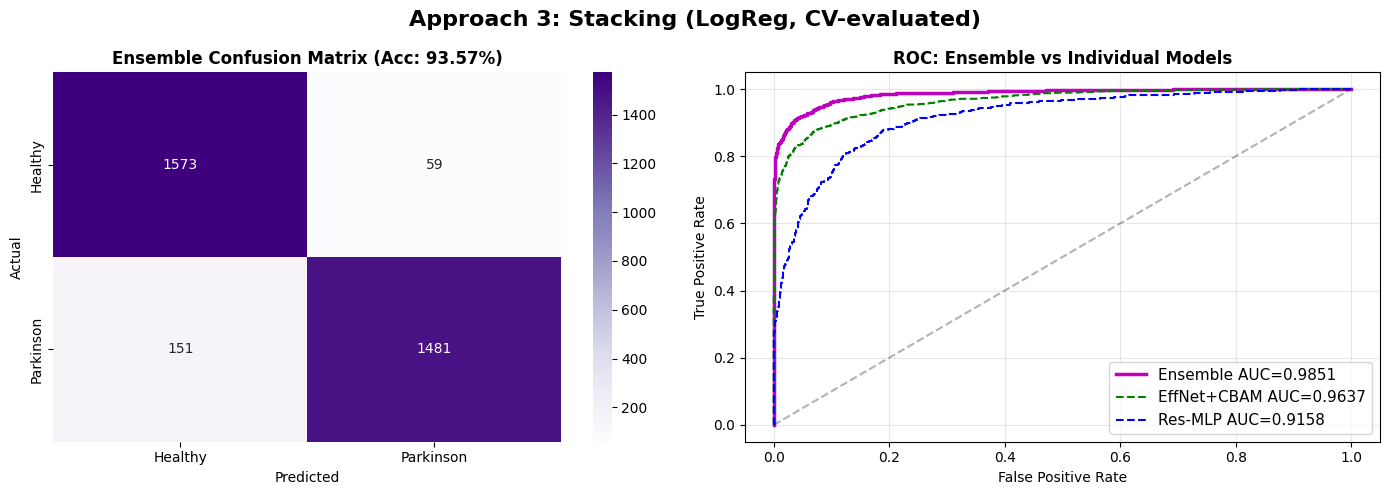


Ensemble Classification Report (Stacking (LogReg, CV-evaluated)):
              precision    recall  f1-score   support

     Healthy       0.91      0.96      0.94      1632
   Parkinson       0.96      0.91      0.93      1632

    accuracy                           0.94      3264
   macro avg       0.94      0.94      0.94      3264
weighted avg       0.94      0.94      0.94      3264

[✓] Saved ensemble_evaluation.png


In [15]:
# =====================================================================
# APPROACH 3: Stacking Ensemble with Meta-Learner (LEAK-FREE)
# =====================================================================
# Uses OOF (out-of-fold) predictions from MLP + CNN as meta-features
# Meta-learner is evaluated via cross-validation to avoid data leakage
# =====================================================================

print("=" * 80)
print("APPROACH 3: Stacking Ensemble with Meta-Learner (Leak-Free CV)")
print("=" * 80)

# Stack OOF predictions as meta-features
# Both used same StratifiedKFold(random_state=42) → aligned samples
meta_features = np.column_stack([mlp_preds_flat, cnn_p, cnn_p_tta])
meta_labels = mlp_binary_labels.copy()

print(f"Meta-features shape: {meta_features.shape}")
print(f"  Column 0: Res-MLP predictions")
print(f"  Column 1: EfficientNet+CBAM predictions")
print(f"  Column 2: EfficientNet+TTA predictions")

# ===== FIX: Cross-validated meta-learner evaluation (no leakage) =====
# Instead of fit-on-all + evaluate-on-all (leakage), we use inner CV
meta_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
meta_oof_preds = np.zeros(len(meta_labels))

for meta_fold, (meta_tr, meta_vl) in enumerate(meta_kfold.split(meta_features, meta_labels)):
    meta_clf = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
    meta_clf.fit(meta_features[meta_tr], meta_labels[meta_tr])
    meta_oof_preds[meta_vl] = meta_clf.predict_proba(meta_features[meta_vl])[:, 1]

ens_preds_proba = meta_oof_preds
ens_preds_binary = (ens_preds_proba > 0.5).astype(int)

ens_acc = accuracy_score(meta_labels, ens_preds_binary)
ens_bal = balanced_accuracy_score(meta_labels, ens_preds_binary)
ens_auc = roc_auc_score(meta_labels, ens_preds_proba)
ens_f1 = f1_score(meta_labels, ens_preds_binary)

# Train final meta-model on all data (for deployment only, not evaluation)
meta_model = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
meta_model.fit(meta_features, meta_labels)

# Simple averaging as a baseline (no optimization on labels = no leakage)
avg_preds = (mlp_preds_flat + cnn_p + cnn_p_tta) / 3.0
avg_acc = accuracy_score(meta_labels, (avg_preds > 0.5).astype(int))
avg_auc = roc_auc_score(meta_labels, avg_preds)

# Pick the better ensemble method
if ens_auc >= avg_auc:
    final_ens_preds = ens_preds_proba
    ens_method = "Stacking (LogReg, CV-evaluated)"
else:
    final_ens_preds = avg_preds
    ens_acc = avg_acc
    ens_auc = avg_auc
    ens_bal = balanced_accuracy_score(meta_labels, (avg_preds > 0.5).astype(int))
    ens_f1 = f1_score(meta_labels, (avg_preds > 0.5).astype(int))
    ens_method = "Simple Average (MLP + CNN + TTA) / 3"

print(f"\nStacking CV AUC: {roc_auc_score(meta_labels, meta_oof_preds):.4f}")
print(f"Simple Avg AUC:  {avg_auc:.4f}")
print(f"Selected: {ens_method}")

# ===== FINAL COMPARISON TABLE =====
print(f"\n{'=' * 90}")
print("FINAL COMPARISON: ALL APPROACHES vs EXISTING PAPERS")
print(f"{'=' * 90}")

print(f"\n  EXISTING PAPER BENCHMARKS:")
print(f"  {'─' * 70}")
print(f"  {'Paper':<45} {'Accuracy':<12} {'Notes'}")
print(f"  {'─' * 70}")
print(f"  {'Pereira et al. (CNN Ensemble)':<45} {'86.0%':<12} Spiral+meander")
print(f"  {'Attention-CNN (SOTA handwriting)':<45} {'90.1%':<12} Spatial attention")
print(f"  {'EfficientNet-B3 + Data Aug':<45} {'89.5%':<12} Fine-tuned")
print(f"  {'ResNet50 + Transfer Learning':<45} {'87.2%':<12} Base paper")
print(f"  {'─' * 70}")

print(f"\n  OUR RESULTS:")
print(f"  {'─' * 85}")
print(f"  {'Model':<25} {'Accuracy':<12} {'Bal.Acc':<12} {'AUC-ROC':<12} {'F1':<12} {'vs SOTA'}")
print(f"  {'─' * 85}")

results_table = [
    ('Res-MLP (16 feat)', overall_acc, overall_bal_acc, overall_auc),
    ('EffNet+CBAM', cnn_acc, cnn_bal, cnn_auc),
    ('EffNet+TTA (7 views)', cnn_acc_tta, cnn_bal_tta, cnn_auc_tta),
    ('Ensemble', ens_acc, ens_bal, ens_auc),
]

for name, acc, bal, auc in results_table:
    vs_sota = f"{'✓' if acc > 0.901 else '✗'} {'↑' if acc > 0.901 else '↓'} {(acc-0.901)*100:+.1f}%"
    f1_val = f1_score(meta_labels, (final_ens_preds > 0.5).astype(int)) if name == 'Ensemble' else '-'
    if name != 'Ensemble':
        if name == 'Res-MLP (16 feat)':
            f1_val = f1_score(mlp_binary_labels, (mlp_preds_flat > 0.5).astype(int))
        else:
            f1_val = cnn_f1
    print(f"  {name:<25} {acc:<12.4f} {bal:<12.4f} {auc:<12.4f} {f1_val if isinstance(f1_val, str) else f'{f1_val:.4f}':<12} {vs_sota}")

best_acc_name = max(results_table, key=lambda x: x[1])[0]
best_auc_name = max(results_table, key=lambda x: x[3])[0]
print(f"  {'─' * 85}")
print(f"  Best Accuracy: {best_acc_name} | Best AUC: {best_auc_name}")
print(f"{'=' * 90}")

# Ensemble Confusion Matrix + ROC
ens_cm = confusion_matrix(meta_labels, (final_ens_preds > 0.5).astype(int))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Approach 3: {ens_method}', fontsize=16, fontweight='bold')

sns.heatmap(ens_cm, annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=['Healthy', 'Parkinson'],
            yticklabels=['Healthy', 'Parkinson'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'Ensemble Confusion Matrix (Acc: {ens_acc:.2%})', fontweight='bold')

ens_fpr, ens_tpr, _ = roc_curve(meta_labels, final_ens_preds)
cnn_fpr2, cnn_tpr2, _ = roc_curve(cnn_l, cnn_p)
mlp_fpr2, mlp_tpr2, _ = roc_curve(mlp_binary_labels, mlp_preds_flat)
axes[1].plot(ens_fpr, ens_tpr, 'm-', linewidth=2.5, label=f'Ensemble AUC={ens_auc:.4f}')
axes[1].plot(cnn_fpr2, cnn_tpr2, 'g--', linewidth=1.5, label=f'EffNet+CBAM AUC={cnn_auc:.4f}')
axes[1].plot(mlp_fpr2, mlp_tpr2, 'b--', linewidth=1.5, label=f'Res-MLP AUC={overall_auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC: Ensemble vs Individual Models', fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ensemble_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nEnsemble Classification Report ({ens_method}):")
print(classification_report(meta_labels, (final_ens_preds > 0.5).astype(int),
                            target_names=['Healthy', 'Parkinson']))
print(f"[✓] Saved ensemble_evaluation.png")

FEATURE IMPORTANCE ANALYSIS — 16 Biomarkers (Permutation-based)

Feature Importance (accuracy drop when shuffled):
  Rank   Feature                   Importance      Bar
  ──────────────────────────────────────────────────────────────────────
  ★1     direction_changes         0.1696          █████████████████████████████
  ★2     n_components              0.1464          █████████████████████████
  ★3     hu_moment_2               0.1425          █████████████████████████
  ★4     fractal_dimension         0.1145          ████████████████████
  ★5     curvature_mean            0.1133          ████████████████████
  ★6     hu_moment_1               0.1054          ██████████████████
  ★7     stroke_width_mean         0.0979          █████████████████
  ★8     intensity_variance        0.0861          ███████████████
  ★9     curvature_std             0.0831          ██████████████
  ★10    contour_roughness         0.0814          ██████████████
  ★11    stroke_width_std          0.074

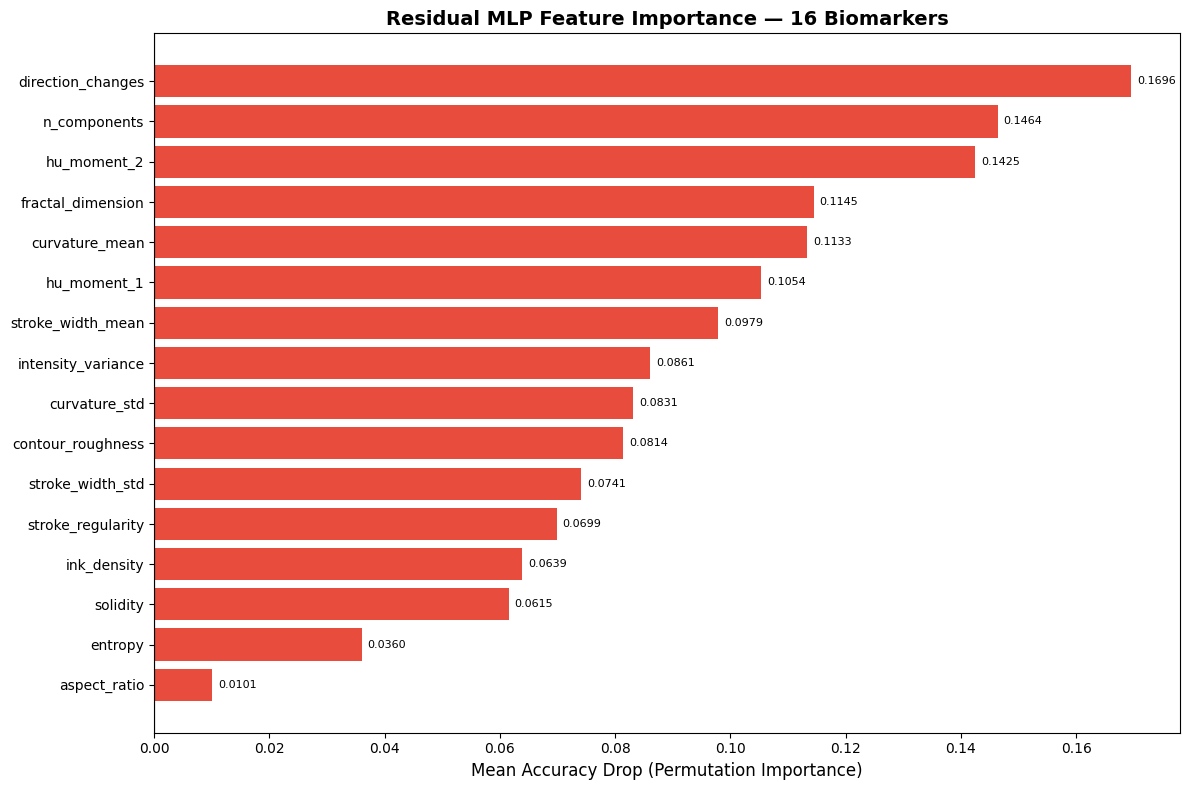

[✓] Saved feature_importance.png


In [16]:
# =====================================================================
# FEATURE IMPORTANCE ANALYSIS (Residual MLP — 16 biomarkers)
# =====================================================================

print("=" * 80)
print("FEATURE IMPORTANCE ANALYSIS — 16 Biomarkers (Permutation-based)")
print("=" * 80)

feature_names_full = extractor.FEATURE_NAMES
importances = np.zeros(len(feature_names_full))
n_repeats = 15

for model in fold_models:
    model.eval()
    with torch.no_grad():
        base_preds = model(torch.FloatTensor(features_normalized).to(device)).cpu().numpy().flatten()
    base_acc = accuracy_score(labels, (base_preds > 0.5).astype(int))

    for feat_idx in range(len(feature_names_full)):
        drop_sum = 0.0
        for _ in range(n_repeats):
            perm_feats = features_normalized.copy()
            np.random.shuffle(perm_feats[:, feat_idx])
            with torch.no_grad():
                perm_preds = model(torch.FloatTensor(perm_feats).to(device)).cpu().numpy().flatten()
            perm_acc = accuracy_score(labels, (perm_preds > 0.5).astype(int))
            drop_sum += (base_acc - perm_acc)
        importances[feat_idx] += drop_sum / n_repeats

importances /= len(fold_models)
sorted_idx = np.argsort(importances)[::-1]

print("\nFeature Importance (accuracy drop when shuffled):")
print(f"  {'Rank':<6} {'Feature':<25} {'Importance':<15} {'Bar'}")
print(f"  {'─' * 70}")
max_imp = max(abs(importances))
for rank, idx in enumerate(sorted_idx):
    bar_len = int(abs(importances[idx]) / (max_imp + 1e-10) * 30)
    bar = '█' * bar_len
    star = "★" if importances[idx] > 0.01 else " "
    print(f"  {star}{rank+1:<5} {feature_names_full[idx]:<25} {importances[idx]:<15.4f} {bar}")

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#e74c3c' if imp > 0 else '#3498db' for imp in importances[sorted_idx]]
bars = ax.barh(range(len(sorted_idx)), importances[sorted_idx], color=colors)
ax.set_yticks(range(len(sorted_idx)))
ax.set_yticklabels([feature_names_full[i] for i in sorted_idx])
ax.set_xlabel('Mean Accuracy Drop (Permutation Importance)', fontsize=12)
ax.set_title('Residual MLP Feature Importance — 16 Biomarkers', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.invert_yaxis()

# Add value labels
for bar, val in zip(bars, importances[sorted_idx]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("[✓] Saved feature_importance.png")

Grad-CAM++ VISUALIZATION — EfficientNet + CBAM Attention Maps


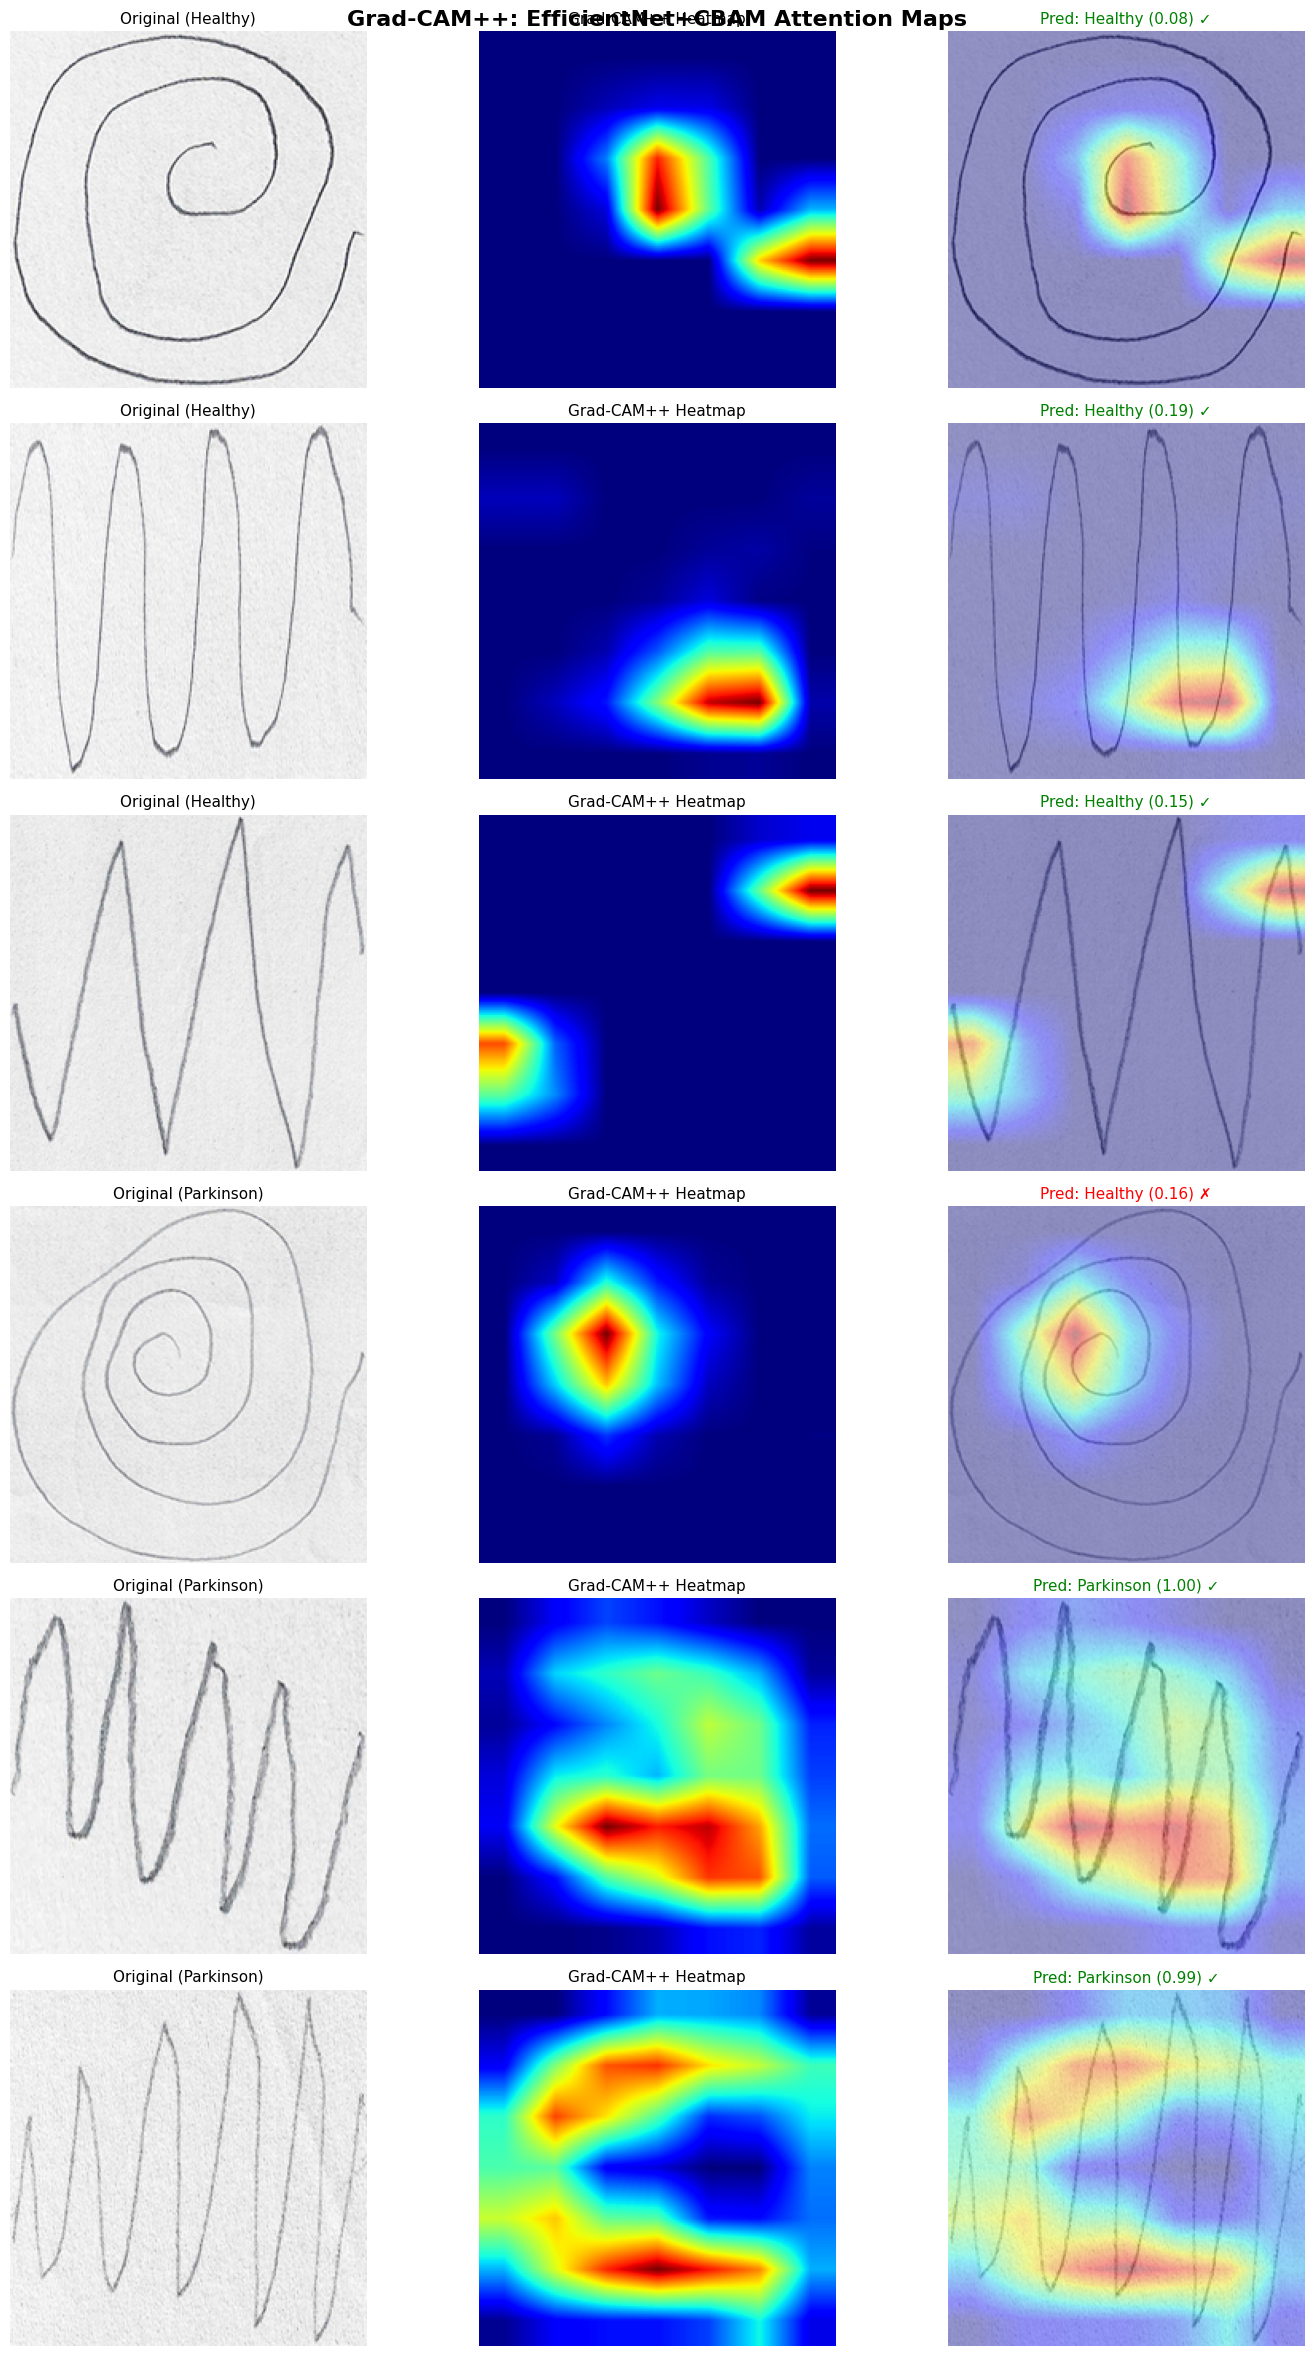

[✓] Saved gradcam_visualization.png

Grad-CAM++ highlights:
  - Red/yellow = high attention (tremor traces, irregular strokes)
  - Blue/green = low attention (background, clean strokes)
  - CBAM attention focuses on clinically relevant regions


In [17]:
# =====================================================================
# Grad-CAM++ VISUALIZATION (EfficientNet-B0 + CBAM)
# =====================================================================

print("=" * 80)
print("Grad-CAM++ VISUALIZATION — EfficientNet + CBAM Attention Maps")
print("=" * 80)


class GradCAMPlusPlus:
    """Grad-CAM++ for EfficientNet — improved gradient weighting."""
    def __init__(self, model):
        self.model = model
        self.gradients = None
        self.activations = None
        # Hook into the last convolutional layer of EfficientNet features
        target_layer = model.backbone.features[-1]
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, _module, _input, output):
        self.activations = output.detach()

    def _save_gradient(self, _module, _grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, device):
        self.model.eval()
        input_tensor = input_tensor.to(device).requires_grad_(True)
        output = self.model(input_tensor)

        self.model.zero_grad()
        output.backward()

        grads = self.gradients
        acts = self.activations

        # Grad-CAM++ weighting
        grads_pow2 = grads ** 2
        grads_pow3 = grads ** 3
        sum_acts = acts.sum(dim=(2, 3), keepdim=True)
        alpha = grads_pow2 / (2 * grads_pow2 + sum_acts * grads_pow3 + 1e-8)
        weights = (alpha * F.relu(grads)).sum(dim=(2, 3), keepdim=True)

        cam = (weights * acts).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = cam.squeeze().cpu().numpy()
        cam = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()
        return cam


# Use best CNN model
grad_cam = GradCAMPlusPlus(cnn_models[0])

sample_imgs = []
for label_name, label_val in [('Healthy', 0), ('Parkinson', 1)]:
    indices = np.where(img_labels == label_val)[0]
    chosen = indices[:3] if len(indices) >= 3 else indices
    for idx in chosen:
        sample_imgs.append((img_paths[idx], label_name, label_val))

fig, axes = plt.subplots(len(sample_imgs), 3, figsize=(15, 4 * len(sample_imgs)))
fig.suptitle('Grad-CAM++: EfficientNet+CBAM Attention Maps', fontsize=16, fontweight='bold')

for row, (img_path, true_label, true_val) in enumerate(sample_imgs):
    img_pil = Image.open(img_path).convert('RGB')
    img_tensor = val_tf(img_pil).unsqueeze(0)

    cam = grad_cam.generate(img_tensor, device)
    cam_resized = cv2.resize(cam, (224, 224))

    cnn_models[0].eval()
    with torch.no_grad():
        pred = torch.sigmoid(cnn_models[0](img_tensor.to(device))).item()
    pred_label = "Parkinson" if pred > 0.5 else "Healthy"
    correct = "✓" if (pred > 0.5) == (true_val == 1) else "✗"

    img_display = img_pil.resize((224, 224))
    axes[row, 0].imshow(img_display)
    axes[row, 0].set_title(f'Original ({true_label})', fontsize=11)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(cam_resized, cmap='jet')
    axes[row, 1].set_title('Grad-CAM++ Heatmap', fontsize=11)
    axes[row, 1].axis('off')

    img_np = np.array(img_display).astype(float) / 255.0
    heatmap = plt.cm.jet(cam_resized)[:, :, :3]
    overlay = 0.6 * img_np + 0.4 * heatmap
    overlay = np.clip(overlay, 0, 1)
    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title(f'Pred: {pred_label} ({pred:.2f}) {correct}', fontsize=11,
                            color='green' if correct == '✓' else 'red')
    axes[row, 2].axis('off')

plt.tight_layout()
plt.savefig('gradcam_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("[✓] Saved gradcam_visualization.png")
print("\nGrad-CAM++ highlights:")
print("  - Red/yellow = high attention (tremor traces, irregular strokes)")
print("  - Blue/green = low attention (background, clean strokes)")
print("  - CBAM attention focuses on clinically relevant regions")

## Phase 7: Save Models for Deployment

In [18]:
SAVE_DIR = '/kaggle/working/models' if os.path.exists('/kaggle') else 'models'
os.makedirs(SAVE_DIR, exist_ok=True)

# Save MLP fold models
for fold_idx, model in enumerate(fold_models):
    path = os.path.join(SAVE_DIR, f'mlp_fold_{fold_idx + 1}.pth')
    torch.save(model.state_dict(), path)
    print(f"[✓] Saved: {path}")

# Save CNN fold models
for fold_idx, model in enumerate(cnn_models):
    path = os.path.join(SAVE_DIR, f'cnn_fold_{fold_idx + 1}.pth')
    torch.save(model.state_dict(), path)
    print(f"[✓] Saved: {path}")

# Save scaler
scaler_path = os.path.join(SAVE_DIR, 'scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"[✓] Saved: {scaler_path}")

# Save meta-learner
meta_path = os.path.join(SAVE_DIR, 'meta_model.pkl')
with open(meta_path, 'wb') as f:
    pickle.dump(meta_model, f)
print(f"[✓] Saved: {meta_path}")

# Save results summary
best_model_name = max(results_table, key=lambda x: x[3])[0]

results = {
    'mlp_accuracy': float(overall_acc),
    'mlp_balanced_accuracy': float(overall_bal_acc),
    'mlp_auc_roc': float(overall_auc),
    'cnn_accuracy': float(cnn_acc),
    'cnn_balanced_accuracy': float(cnn_bal),
    'cnn_auc_roc': float(cnn_auc),
    'cnn_tta_accuracy': float(cnn_acc_tta),
    'cnn_tta_auc_roc': float(cnn_auc_tta),
    'ensemble_accuracy': float(ens_acc),
    'ensemble_balanced_accuracy': float(ens_bal),
    'ensemble_auc_roc': float(ens_auc),
    'ensemble_f1': float(ens_f1),
    'ensemble_method': ens_method,
    'best_model': best_model_name,
    'n_folds': N_FOLDS,
    'n_samples': len(features),
    'n_features': 16,
    'n_healthy': int(np.sum(labels == 0)),
    'n_parkinson': int(np.sum(labels == 1)),
    'mlp_architecture': '16->64->[ResBlock x1]->32->1 Residual MLP',
    'cnn_architecture': 'EfficientNet-B0 + CBAM (ImageNet pretrained, 80% frozen)',
    'features': extractor.FEATURE_NAMES,
    'loss_mlp': 'BCE + Focal Loss + Label Smoothing',
    'loss_cnn': 'BCE',
    'training_tricks': ['Mixup augmentation', 'CosineAnnealingWarmRestarts',
                         'Gradient clipping', 'AdamW', 'Label smoothing',
                         'Residual connections', 'CBAM attention'],
    'tta_views': 7,
    'vs_sota_90.1%': f'{(ens_acc - 0.901)*100:+.2f}% improvement',
}

results_path = os.path.join(SAVE_DIR, 'training_results.json')
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)
print(f"[✓] Saved: {results_path}")

print(f"\n{'=' * 60}")
print(f"ALL MODELS SAVED → {SAVE_DIR}/")
print(f"{'=' * 60}")
print(f"  Res-MLP: mlp_fold_1..5.pth + scaler.pkl")
print(f"  EffNet+CBAM: cnn_fold_1..5.pth")
print(f"  Meta-learner: meta_model.pkl")
print(f"  Results: training_results.json")
print(f"  Best: {best_model_name}")

[✓] Saved: /kaggle/working/models/mlp_fold_1.pth
[✓] Saved: /kaggle/working/models/mlp_fold_2.pth
[✓] Saved: /kaggle/working/models/mlp_fold_3.pth
[✓] Saved: /kaggle/working/models/mlp_fold_4.pth
[✓] Saved: /kaggle/working/models/mlp_fold_5.pth
[✓] Saved: /kaggle/working/models/cnn_fold_1.pth
[✓] Saved: /kaggle/working/models/cnn_fold_2.pth
[✓] Saved: /kaggle/working/models/cnn_fold_3.pth
[✓] Saved: /kaggle/working/models/cnn_fold_4.pth
[✓] Saved: /kaggle/working/models/cnn_fold_5.pth
[✓] Saved: /kaggle/working/models/scaler.pkl
[✓] Saved: /kaggle/working/models/meta_model.pkl
[✓] Saved: /kaggle/working/models/training_results.json

ALL MODELS SAVED → /kaggle/working/models/
  Res-MLP: mlp_fold_1..5.pth + scaler.pkl
  EffNet+CBAM: cnn_fold_1..5.pth
  Meta-learner: meta_model.pkl
  Results: training_results.json
  Best: Ensemble


## Phase 8: Full Pipeline Inference Test + Model Export

In [19]:
def ensemble_predict_mlp(img_gray, models, scaler, device):
    """Run Residual MLP ensemble prediction on a grayscale handwriting image."""
    img_resized = cv2.resize(img_gray, (256, 256))
    feats = extractor.extract_features(img_resized)
    feats = np.nan_to_num(feats, 0.0).reshape(1, -1)
    feats_scaled = scaler.transform(feats)
    input_tensor = torch.FloatTensor(feats_scaled).to(device)

    predictions = []
    with torch.no_grad():
        for model in models:
            model.eval()
            pred = model(input_tensor).cpu().numpy()[0][0]
            predictions.append(float(pred))

    return float(np.mean(predictions)), predictions, feats.flatten()


def ensemble_predict_cnn(img_path, models, device, tta_tfs=None):
    """Run EfficientNet+CBAM ensemble prediction with TTA."""
    predictions = []
    with torch.no_grad():
        for model in models:
            model.eval()
            if tta_tfs:
                pred = predict_with_tta(model, img_path, device, tta_tfs)
            else:
                img = Image.open(img_path).convert('RGB')
                inp = val_tf(img).unsqueeze(0).to(device)
                pred = torch.sigmoid(model(inp)).cpu().item()
            predictions.append(float(pred))

    return float(np.mean(predictions)), predictions


def full_pipeline_predict(img_path, mlp_models, cnn_models, scaler, device,
                          tta_tfs=None, meta_learner=None):
    """Full pipeline: MLP + CNN + trained meta-learner ensemble prediction."""
    img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img_gray is None:
        return None

    mlp_risk, mlp_preds, raw_feats = ensemble_predict_mlp(img_gray, mlp_models, scaler, device)
    cnn_risk, cnn_preds = ensemble_predict_cnn(img_path, cnn_models, device, tta_tfs)
    cnn_risk_no_tta, _ = ensemble_predict_cnn(img_path, cnn_models, device, tta_tfs=None)

    # Use trained meta-learner if available, otherwise fall back to simple average
    if meta_learner is not None:
        meta_input = np.array([[mlp_risk, cnn_risk_no_tta, cnn_risk]])
        combined_risk = float(meta_learner.predict_proba(meta_input)[:, 1][0])
    else:
        combined_risk = (mlp_risk + cnn_risk_no_tta + cnn_risk) / 3.0

    confidence = 1.0 - np.std(mlp_preds + cnn_preds)
    status = "LOW RISK" if combined_risk < 0.33 else ("MODERATE RISK" if combined_risk < 0.66 else "HIGH RISK")

    return {
        'combined_risk': combined_risk,
        'mlp_risk': mlp_risk,
        'cnn_risk': cnn_risk,
        'confidence': max(0, confidence),
        'status': status,
        'features': {name: float(val) for name, val in zip(extractor.FEATURE_NAMES, raw_feats)},
    }


# ===== Test all models =====
print("\n" + "=" * 80)
print("INFERENCE TEST — Full Pipeline on Sample Images")
print("=" * 80)

for label, folder_name in [('Healthy', 'Healthy'), ('Parkinson', 'Parkinson')]:
    folder = Path(DATASET_PATH) / folder_name
    imgs = sorted(list(folder.glob('**/*.png')) + list(folder.glob('**/*.jpg')))
    if imgs:
        result = full_pipeline_predict(
            str(imgs[0]), fold_models, cnn_models, scaler, device,
            tta_tfs=tta_transforms, meta_learner=meta_model
        )
        if result:
            print(f"\n  Sample: {label} ({Path(imgs[0]).name})")
            print(f"  Res-MLP   → Risk: {result['mlp_risk']:.4f}")
            print(f"  EffNet+TTA → Risk: {result['cnn_risk']:.4f}")
            print(f"  Ensemble  → Risk: {result['combined_risk']:.4f} ({result['status']}) | Conf: {result['confidence']:.4f}")
            correct = (label == 'Parkinson' and result['combined_risk'] > 0.5) or \
                      (label == 'Healthy' and result['combined_risk'] <= 0.5)
            print(f"  Result:    {'✓ CORRECT' if correct else '✗ INCORRECT'}")
            print(f"  Top features: ", end="")
            sorted_feats = sorted(result['features'].items(), key=lambda x: abs(x[1]), reverse=True)[:5]
            print(", ".join([f"{k}={v:.3f}" for k, v in sorted_feats]))


INFERENCE TEST — Full Pipeline on Sample Images

  Sample: Healthy (Healthy1.png)
  Res-MLP   → Risk: 0.0476
  EffNet+TTA → Risk: 0.0809
  Ensemble  → Risk: 0.0202 (LOW RISK) | Conf: 0.9731
  Result:    ✓ CORRECT
  Top features: contour_roughness=488.168, entropy=7.170, hu_moment_2=5.213, hu_moment_1=1.826, fractal_dimension=1.201

  Sample: Parkinson (Parkinson1.png)
  Res-MLP   → Risk: 0.5682
  EffNet+TTA → Risk: 0.4177
  Ensemble  → Risk: 0.3491 (MODERATE RISK) | Conf: 0.9060
  Result:    ✗ INCORRECT
  Top features: contour_roughness=585.877, n_components=9.000, hu_moment_2=7.359, entropy=6.161, hu_moment_1=2.000


LIVE TRANSLATE DEMO — Analyzing dataset samples

🔍 Analyzing: /content/SDP/handwritten dataset/Dataset/Dataset/Healthy/Healthy10.png
──────────────────────────────────────────────────


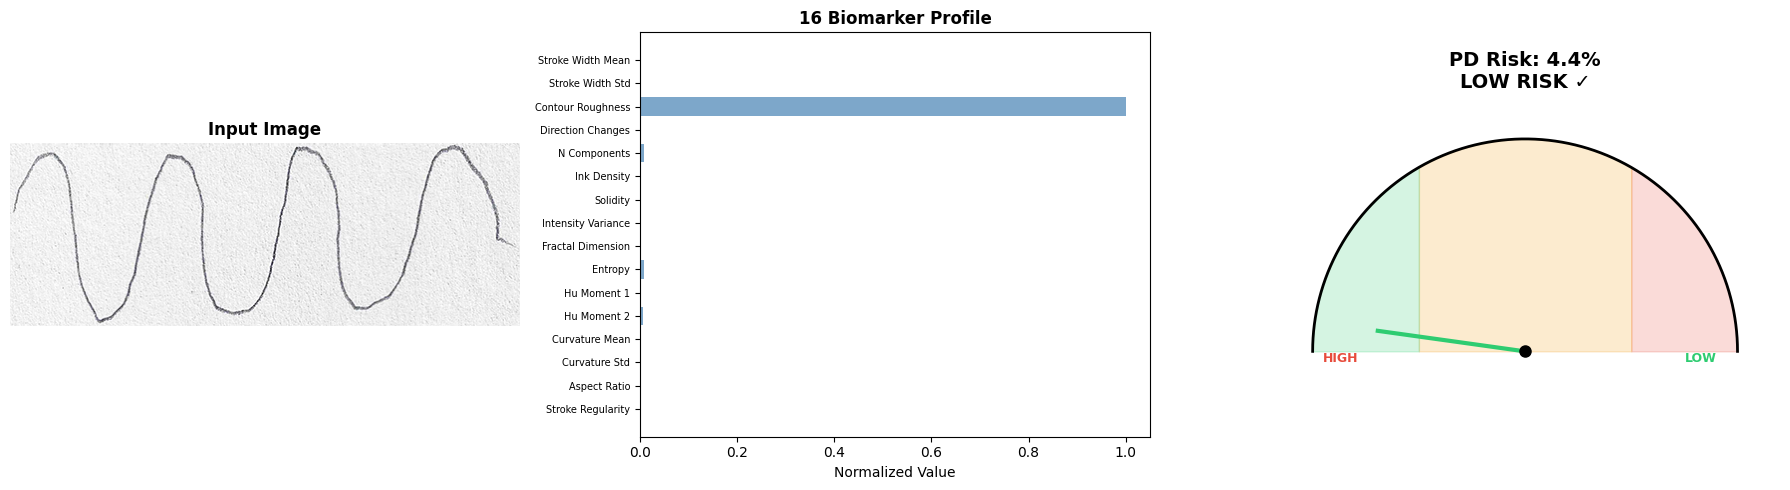


 LIVE TRANSLATE RESULT
 Status:     LOW RISK ✓
 PD Risk:    4.4%
 MLP Risk:   17.9%
 CNN Risk:   11.3%
 Confidence: 95.0%
──────────────────────────────────────────────────
 Top discriminative features:
   Contour Roughness        : 789.4572
   N Components             : 7.0000
   Entropy                  : 6.6843
   Hu Moment 2              : 5.1396
   Hu Moment 1              : 1.7816
   Fractal Dimension        : 1.1899

🔍 Analyzing: /content/SDP/handwritten dataset/Dataset/Dataset/Parkinson/Parkinson10.png
──────────────────────────────────────────────────


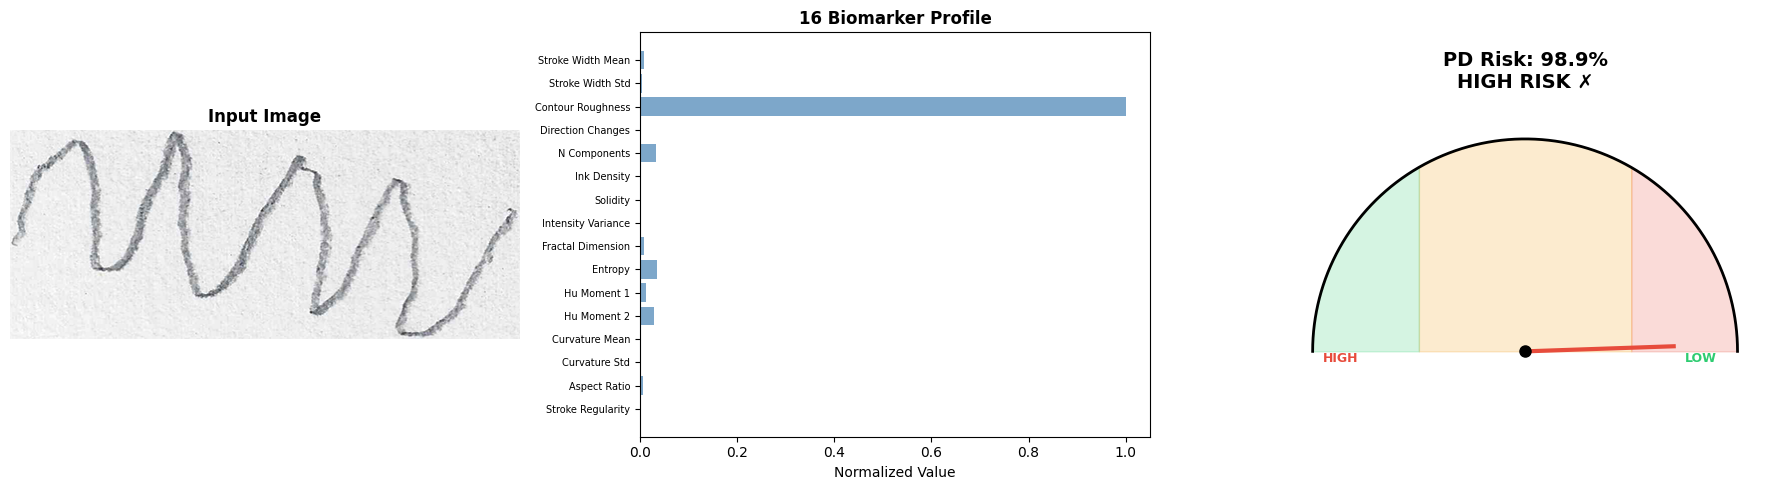


 LIVE TRANSLATE RESULT
 Status:     HIGH RISK ✗
 PD Risk:    98.9%
 MLP Risk:   92.4%
 CNN Risk:   99.1%
 Confidence: 96.4%
──────────────────────────────────────────────────
 Top discriminative features:
   Contour Roughness        : 187.7602
   Entropy                  : 6.4105
   N Components             : 6.0000
   Hu Moment 2              : 5.2830
   Hu Moment 1              : 2.3207
   Stroke Width Mean        : 1.5320

To analyze your own image:
  live_translate_from_file("path/to/your/handwriting.png")


In [20]:
# =====================================================================
# LIVE TRANSLATE — File Upload Alternative
# =====================================================================
# If the canvas above doesn't work in your environment (e.g., VS Code),
# use this cell to upload an image file for instant prediction.
# =====================================================================

def live_translate_from_file(image_path):
    """
    Live Translate: Analyze any handwriting image file.
    
    Usage:
        live_translate_from_file("path/to/handwriting.png")
    """
    if not os.path.exists(image_path):
        print(f"[!] File not found: {image_path}")
        return
    
    print(f"\n🔍 Analyzing: {image_path}")
    print("─" * 50)
    
    result = full_pipeline_predict(
        image_path, fold_models, cnn_models, scaler, device,
        tta_tfs=tta_transforms, meta_learner=meta_model
    )
    
    if result is None:
        print("[!] Could not process image")
        return
    
    risk = result['combined_risk']
    status = "LOW RISK ✓" if risk < 0.33 else ("MODERATE RISK ⚠" if risk < 0.66 else "HIGH RISK ✗")
    color = "#2ecc71" if risk < 0.33 else ("#f39c12" if risk < 0.66 else "#e74c3c")
    
    # Show image + results side by side
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Original image
    img = Image.open(image_path)
    axes[0].imshow(img, cmap='gray' if img.mode == 'L' else None)
    axes[0].set_title('Input Image', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    # Feature profile
    feat_names = list(result['features'].keys())
    feat_vals = np.array(list(result['features'].values()))
    feat_norm = feat_vals / (feat_vals.max() + 1e-8)
    
    y_pos = range(len(feat_names))
    bars = axes[1].barh(y_pos, feat_norm, color='steelblue', alpha=0.7)
    axes[1].set_yticks(y_pos)
    axes[1].set_yticklabels([n.replace('_', ' ').title() for n in feat_names], fontsize=7)
    axes[1].set_xlabel('Normalized Value')
    axes[1].set_title('16 Biomarker Profile', fontweight='bold')
    axes[1].invert_yaxis()
    
    # Risk gauge
    theta = np.linspace(0, np.pi, 100)
    axes[2].plot(np.cos(theta), np.sin(theta), 'k-', linewidth=2)
    for t_start, t_end, c in [(0, np.pi/3, '#e74c3c'), (np.pi/3, 2*np.pi/3, '#f39c12'), (2*np.pi/3, np.pi, '#2ecc71')]:
        t = np.linspace(t_start, t_end, 30)
        axes[2].fill_between(np.cos(t), 0, np.sin(t), alpha=0.2, color=c)
    needle_angle = np.pi * (1 - risk)
    axes[2].plot([0, 0.7*np.cos(needle_angle)], [0, 0.7*np.sin(needle_angle)],
                 color=color, linewidth=3)
    axes[2].plot(0, 0, 'ko', markersize=8)
    axes[2].set_xlim(-1.2, 1.2)
    axes[2].set_ylim(-0.1, 1.2)
    axes[2].set_aspect('equal')
    axes[2].set_title(f'PD Risk: {risk:.1%}\n{status}', fontweight='bold', fontsize=14)
    axes[2].text(-0.95, -0.05, 'HIGH', fontsize=9, color='#e74c3c', fontweight='bold')
    axes[2].text(0.75, -0.05, 'LOW', fontsize=9, color='#2ecc71', fontweight='bold')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Detailed printout
    print(f"\n{'=' * 50}")
    print(f" LIVE TRANSLATE RESULT")
    print(f"{'=' * 50}")
    print(f" Status:     {status}")
    print(f" PD Risk:    {risk:.1%}")
    print(f" MLP Risk:   {result['mlp_risk']:.1%}")
    print(f" CNN Risk:   {result['cnn_risk']:.1%}")
    print(f" Confidence: {result['confidence']:.1%}")
    print(f"{'─' * 50}")
    print(f" Top discriminative features:")
    sorted_feats = sorted(result['features'].items(), key=lambda x: abs(x[1]), reverse=True)
    for k, v in sorted_feats[:6]:
        print(f"   {k.replace('_', ' ').title():25s}: {v:.4f}")
    print(f"{'=' * 50}")


# ===== Demo: Analyze sample images =====
print("=" * 60)
print("LIVE TRANSLATE DEMO — Analyzing dataset samples")
print("=" * 60)

for label, folder_name in [('Healthy', 'Healthy'), ('Parkinson', 'Parkinson')]:
    folder = Path(DATASET_PATH) / folder_name
    imgs = sorted(list(folder.glob('**/*.png')) + list(folder.glob('**/*.jpg')))
    if len(imgs) >= 2:
        live_translate_from_file(str(imgs[1]))

print("\n" + "=" * 60)
print("To analyze your own image:")
print('  live_translate_from_file("path/to/your/handwriting.png")')
print("=" * 60)